# Knee Osteoarthritis Severity Grading & Explainable AI (XAI)

This notebook contains the complete, high-performance end-to-end deep learning pipeline for Knee Osteoarthritis classification (3-class: Healthy vs. Moderate vs. Severe).

It includes:
1. **ResNet50 Classifier** (CNN)
2. **Vision Transformer (ViT) Classifier** (Global Self-Attention)
3. **Combined Hybrid Model** (Concatenated ResNet50 + ViT + DINO ViT)
4. **Test-Time Augmentation (TTA)** & **Model Ensemble Voting**
5. **Multi-XAI Comparison** (Grad-CAM, Grad-CAM++, Layer-CAM, Score-CAM, and Integrated Gradients)
6. **Hybrid Branch Attribution** (CAM on CNN, Integrated Gradients on ViT, DINO, and Fusion branches)

In [1]:
# ============================================================
# IMPORTS AND CONFIGURATION
# ============================================================
import os
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import timm

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from torch.amp import autocast, GradScaler

# ============================================================
# CONFIG
# ============================================================
DATA_ROOT = "dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")
AUTO_DIR  = os.path.join(DATA_ROOT, "auto_test")

IMG_SIZE = 224
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# CLASS REMAPPING (5 → 3)
# ============================================================
CLASS_MAP = {
    '0': 'Healthy',
    '1': 'Healthy',
    '2': 'Healthy',
    '3': 'Moderate',
    '4': 'Severe'
}

FINAL_CLASSES = ['Healthy', 'Moderate', 'Severe']
CLASS_TO_IDX = {c: i for i, c in enumerate(FINAL_CLASSES)}
NUM_CLASSES = 3

c:\Users\setty\.gemini\antigravity-ide\scratch\koa_improved_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ============================================================
# DATA TRANSFORMS & CUSTOM DATASET
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.15, 0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class RemappedImageFolder(ImageFolder):
    def __getitem__(self, index):
        path, _ = self.samples[index]
        original = os.path.basename(os.path.dirname(path))
        label = CLASS_MAP[original]
        target = CLASS_TO_IDX[label]
        img = self.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, target

# ============================================================
# LOADERS
# ============================================================
train_ds = RemappedImageFolder(TRAIN_DIR, train_tfms)
val_ds   = RemappedImageFolder(VAL_DIR, val_tfms)
test_ds  = RemappedImageFolder(TEST_DIR, val_tfms)
auto_ds  = RemappedImageFolder(AUTO_DIR, val_tfms)

# Compute class weights for WeightedRandomSampler to address class imbalance
train_targets = [y for _, y in train_ds]
class_counts = np.bincount(train_targets)
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_targets])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
auto_loader  = DataLoader(auto_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Classes:", FINAL_CLASSES)
print(f"Dataset Size - Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Classes: ['Healthy', 'Moderate', 'Severe']
Dataset Size - Train: 5778, Val: 826, Test: 1656


In [3]:
# ============================================================
# LOSS, OPTIMIZATION & TRAINING HELPERS (WITH AMP)
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler("cuda")

def evaluate(model, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            if isinstance(out, tuple):
                out = out[0]
            preds.extend(out.argmax(1).cpu().numpy())
            gts.extend(y.numpy())
    return accuracy_score(gts, preds)

def train_model(model, epochs, lr, name):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )
    # Cosine Annealing Learning Rate Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                # Handle model output structure (some custom models return tuple)
                out = model(x)
                if isinstance(out, tuple):
                    out = out[0]
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

            # Print batch-level progress every 50 steps
            if (i + 1) % 50 == 0 or (i + 1) == len(train_loader):
                print(f"  [Epoch {epoch+1}] Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # Update learning rate
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        acc = evaluate(model, val_loader)
        print(f"{name} | Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc*100:.2f}%")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f"./{name}.pth")
            print(f"[SAVE] Saved new best weights to {name}.pth")

In [4]:
# ============================================================
# CNN MODEL (RESNET50) TRAINING
# ============================================================
cnn_model = timm.create_model("resnet50", pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

print("Starting ResNet50 end-to-end training...")
train_model(cnn_model, epochs=12, lr=3e-4, name="cnn_model")


Starting ResNet50 end-to-end training...
  [Epoch 1] Batch 50/362 | Loss: 1.0610
  [Epoch 1] Batch 100/362 | Loss: 0.7086
  [Epoch 1] Batch 150/362 | Loss: 0.6362
  [Epoch 1] Batch 200/362 | Loss: 0.5011
  [Epoch 1] Batch 250/362 | Loss: 0.7184
  [Epoch 1] Batch 300/362 | Loss: 0.7004
  [Epoch 1] Batch 350/362 | Loss: 0.4207
  [Epoch 1] Batch 362/362 | Loss: 0.4324
cnn_model | Epoch 1/12 | LR: 0.000295 | Loss: 0.7528 | Val Acc: 86.68%
[SAVE] Saved new best weights to cnn_model.pth
  [Epoch 2] Batch 50/362 | Loss: 0.3374
  [Epoch 2] Batch 100/362 | Loss: 0.6181
  [Epoch 2] Batch 150/362 | Loss: 0.3414
  [Epoch 2] Batch 200/362 | Loss: 0.4544
  [Epoch 2] Batch 250/362 | Loss: 0.4665
  [Epoch 2] Batch 300/362 | Loss: 0.3414
  [Epoch 2] Batch 350/362 | Loss: 0.3448
  [Epoch 2] Batch 362/362 | Loss: 0.6791
cnn_model | Epoch 2/12 | LR: 0.000280 | Loss: 0.4945 | Val Acc: 88.62%
[SAVE] Saved new best weights to cnn_model.pth
  [Epoch 3] Batch 50/362 | Loss: 0.4360
  [Epoch 3] Batch 100/362 | L

In [5]:
# ============================================================
# VIT MODEL (HEAD -> PARTIAL UNFREEZE) TRAINING
# ============================================================
vit_model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

# Stage 1: Fine-tune Classification Head Only
print(">>> Stage 1: Training ViT Classification Head Only...")
for n, p in vit_model.named_parameters():
    p.requires_grad = ("head" in n)

train_model(vit_model, epochs=5, lr=1e-3, name="vit_head")

# Stage 2: Fine-tune Top Transformer Blocks
print("\n>>> Stage 2: Unfreezing Blocks 8-11 for Fine-Tuning...")
for n, p in vit_model.named_parameters():
    p.requires_grad = any(b in n for b in ["blocks.8","blocks.9","blocks.10","blocks.11","head"])

train_model(vit_model, epochs=10, lr=1e-4, name="vit_model")


>>> Stage 1: Training ViT Classification Head Only...
  [Epoch 1] Batch 50/362 | Loss: 0.9051
  [Epoch 1] Batch 100/362 | Loss: 0.8551
  [Epoch 1] Batch 150/362 | Loss: 0.8675
  [Epoch 1] Batch 200/362 | Loss: 1.1959
  [Epoch 1] Batch 250/362 | Loss: 0.8472
  [Epoch 1] Batch 300/362 | Loss: 0.8819
  [Epoch 1] Batch 350/362 | Loss: 0.8477
  [Epoch 1] Batch 362/362 | Loss: 0.4739
vit_head | Epoch 1/5 | LR: 0.000905 | Loss: 0.8656 | Val Acc: 82.69%
[SAVE] Saved new best weights to vit_head.pth
  [Epoch 2] Batch 50/362 | Loss: 0.8395
  [Epoch 2] Batch 100/362 | Loss: 0.9511
  [Epoch 2] Batch 150/362 | Loss: 0.6495
  [Epoch 2] Batch 200/362 | Loss: 0.7320
  [Epoch 2] Batch 250/362 | Loss: 0.8503
  [Epoch 2] Batch 300/362 | Loss: 0.6541
  [Epoch 2] Batch 350/362 | Loss: 0.5031
  [Epoch 2] Batch 362/362 | Loss: 0.8579
vit_head | Epoch 2/5 | LR: 0.000655 | Loss: 0.7607 | Val Acc: 69.01%
  [Epoch 3] Batch 50/362 | Loss: 0.6185
  [Epoch 3] Batch 100/362 | Loss: 0.6172
  [Epoch 3] Batch 150/362 |

In [6]:
# ============================================================
# DINO VIT MODEL (HEAD -> PARTIAL UNFREEZE) TRAINING
# ============================================================
dino_model = timm.create_model("vit_base_patch16_224.dino", pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

# Stage 1: Fine-tune Classification Head Only
print(">>> Stage 1: Training DINO ViT Classification Head Only...")
for n, p in dino_model.named_parameters():
    p.requires_grad = ("head" in n)

train_model(dino_model, epochs=5, lr=1e-3, name="dino_head")

# Stage 2: Fine-tune Top Transformer Blocks
print("\n>>> Stage 2: Unfreezing DINO Blocks 8-11 for Fine-Tuning...")
for n, p in dino_model.named_parameters():
    p.requires_grad = any(b in n for b in ["blocks.8", "blocks.9", "blocks.10", "blocks.11", "head"])

train_model(dino_model, epochs=10, lr=1e-4, name="dino_model")

>>> Stage 1: Training DINO ViT Classification Head Only...
  [Epoch 1] Batch 50/362 | Loss: 0.9375
  [Epoch 1] Batch 100/362 | Loss: 0.6190
  [Epoch 1] Batch 150/362 | Loss: 0.7557
  [Epoch 1] Batch 200/362 | Loss: 0.8385
  [Epoch 1] Batch 250/362 | Loss: 0.9197
  [Epoch 1] Batch 300/362 | Loss: 0.5805
  [Epoch 1] Batch 350/362 | Loss: 0.5678
  [Epoch 1] Batch 362/362 | Loss: 2.2325
dino_head | Epoch 1/5 | LR: 0.000905 | Loss: 0.7645 | Val Acc: 74.94%
[SAVE] Saved new best weights to dino_head.pth
  [Epoch 2] Batch 50/362 | Loss: 0.5509
  [Epoch 2] Batch 100/362 | Loss: 0.5978
  [Epoch 2] Batch 150/362 | Loss: 0.6053
  [Epoch 2] Batch 200/362 | Loss: 0.6381
  [Epoch 2] Batch 250/362 | Loss: 0.7978
  [Epoch 2] Batch 300/362 | Loss: 0.6869
  [Epoch 2] Batch 350/362 | Loss: 0.4433
  [Epoch 2] Batch 362/362 | Loss: 0.4186
dino_head | Epoch 2/5 | LR: 0.000655 | Loss: 0.6547 | Val Acc: 73.73%
  [Epoch 3] Batch 50/362 | Loss: 0.6465
  [Epoch 3] Batch 100/362 | Loss: 0.5618
  [Epoch 3] Batch 1

In [8]:
# ============================================================
# LOSS, OPTIMIZATION & TRAINING HELPERS (WITH AMP)
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler("cuda")

def evaluate(model, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            # Handle tuple output (e.g., from Hybrid model)
            if isinstance(out, tuple):
                out = out[0]
            preds.extend(out.argmax(1).cpu().numpy())
            gts.extend(y.numpy())
    return accuracy_score(gts, preds)

def train_model(model, epochs, lr, name):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )
    # Cosine Annealing Learning Rate Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                # Handle model output structure (some custom models return tuple)
                out = model(x)
                if isinstance(out, tuple):
                    out = out[0]
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

            # Print batch-level progress every 50 steps
            if (i + 1) % 50 == 0 or (i + 1) == len(train_loader):
                print(f"  [Epoch {epoch+1}] Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # Update learning rate
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        acc = evaluate(model, val_loader)
        print(f"{name} | Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc*100:.2f}%")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f"./{name}.pth")
            print(f"[SAVE] Saved new best weights to {name}.pth")


In [9]:
# ============================================================
# COMBINED HYBRID MODEL (CNN + ViT + DINO) DEFINITION & TRAINING
# ============================================================
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = timm.create_model("resnet50", pretrained=False, num_classes=0)
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=0)
        self.dino = timm.create_model("vit_base_patch16_224.dino", pretrained=True, num_classes=0)

        # Freeze DINO backbone (self-supervised structural features)
        for p in self.dino.parameters():
            p.requires_grad = False

        dim = self.cnn.num_features + self.vit.num_features + self.dino.num_features

        self.head = nn.Sequential(
            nn.Linear(dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        f_cnn = self.cnn(x)
        f_vit = self.vit(x)
        f_dino = self.dino(x)
        fused = torch.cat([f_cnn, f_vit, f_dino], dim=1)
        return self.head(fused), f_cnn, f_vit, f_dino

hybrid_model = HybridModel().to(DEVICE)

# Load pretrained branch weights individually to be robust against missing files
for branch, filename in [("cnn", "cnn_model.pth"), ("vit", "vit_model.pth"), ("dino", "dino_model.pth")]:
    try:
        getattr(hybrid_model, branch).load_state_dict(torch.load(filename, map_location=DEVICE), strict=False)
        print(f"Loaded pretrained weights for {branch.upper()} branch from {filename}.")
    except FileNotFoundError:
        print(f"Warning: {filename} not found. Branch {branch.upper()} will use default/scratch weights.")

# Stage 1: Train Head Only
print(">>> Stage 1: Fine-Tuning Hybrid Classifier Head...")
for p in hybrid_model.cnn.parameters(): p.requires_grad = False
for p in hybrid_model.vit.parameters(): p.requires_grad = False

train_model(hybrid_model, epochs=5, lr=1e-3, name="hybrid_head")

# Stage 2: Joint Backbone Training
print("\n>>> Stage 2: Unfreezing CNN Backbone and ViT Blocks 8-11...")
for p in hybrid_model.cnn.parameters(): p.requires_grad = True
for n, p in hybrid_model.vit.named_parameters():
    p.requires_grad = any(b in n for b in ["blocks.8","blocks.9","blocks.10","blocks.11"])

train_model(hybrid_model, epochs=10, lr=2e-4, name="hybrid_model")

C:\Users\setty\AppData\Local\Temp\ipykernel_7816\4239888616.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  getattr(hybrid_model, branch).load_state_dict(torch.load(fil

Loaded pretrained weights for CNN branch from cnn_model.pth.
Loaded pretrained weights for VIT branch from vit_model.pth.
Loaded pretrained weights for DINO branch from dino_model.pth.
>>> Stage 1: Fine-Tuning Hybrid Classifier Head...
  [Epoch 1] Batch 50/362 | Loss: 0.3187
  [Epoch 1] Batch 100/362 | Loss: 0.3520
  [Epoch 1] Batch 150/362 | Loss: 0.3331
  [Epoch 1] Batch 200/362 | Loss: 0.3310
  [Epoch 1] Batch 250/362 | Loss: 0.3108
  [Epoch 1] Batch 300/362 | Loss: 0.3321
  [Epoch 1] Batch 350/362 | Loss: 0.3465
  [Epoch 1] Batch 362/362 | Loss: 0.4535
hybrid_head | Epoch 1/5 | LR: 0.000905 | Loss: 0.3543 | Val Acc: 95.04%
[SAVE] Saved new best weights to hybrid_head.pth
  [Epoch 2] Batch 50/362 | Loss: 0.4239
  [Epoch 2] Batch 100/362 | Loss: 0.3000
  [Epoch 2] Batch 150/362 | Loss: 0.3118
  [Epoch 2] Batch 200/362 | Loss: 0.3060
  [Epoch 2] Batch 250/362 | Loss: 0.3240
  [Epoch 2] Batch 300/362 | Loss: 0.3117
  [Epoch 2] Batch 350/362 | Loss: 0.4929
  [Epoch 2] Batch 362/362 | Lo

In [10]:
# ============================================================
# EVALUATION ON TEST & AUTOTEST SETS
# ============================================================
# Load best weights
try:
    cnn_model.load_state_dict(torch.load("cnn_model.pth", map_location=DEVICE))
    vit_model.load_state_dict(torch.load("vit_model.pth", map_location=DEVICE))
    dino_model.load_state_dict(torch.load("dino_model.pth", map_location=DEVICE))
    hybrid_model.load_state_dict(torch.load("hybrid_model.pth", map_location=DEVICE))
    print("Loaded best weights for all models.")
except FileNotFoundError as e:
    print(f"Warning: Could not load some weights. Proceeding with current memory weights. Error: {e}")

for name, ds in [("TEST", test_ds), ("AUTOTEST", auto_ds)]:
    # Compute TTA probabilities
    cnn_p = tta_predict(cnn_model, ds)
    vit_p = tta_predict(vit_model, ds)
    dino_p = tta_predict(dino_model, ds)
    hyb_p = tta_predict(hybrid_model, ds)

    # Ensemble Voting
    final_p = (cnn_p + vit_p + dino_p + hyb_p) / 4
    y_pred = np.argmax(final_p, axis=1)
    
    # Extract ground truth labels safely
    y_true = [y for _, y in ds]

    print(f"\n===== {name} ENSEMBLE RESULTS =====")
    print("Accuracy: ", accuracy_score(y_true, y_pred) * 100)
    print(classification_report(y_true, y_pred, target_names=FINAL_CLASSES))

    # Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True, fmt="d", cmap="Blues",
                xticklabels=FINAL_CLASSES,
                yticklabels=FINAL_CLASSES)
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.show()

C:\Users\setty\AppData\Local\Temp\ipykernel_7816\1391098337.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load("cnn_model.pth", map_loc

Loaded best weights for all models.

===== TEST ENSEMBLE RESULTS =====
Accuracy:  94.8671497584541
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.97      1382
    Moderate       0.79      0.84      0.82       223
      Severe       0.90      0.84      0.87        51

    accuracy                           0.95      1656
   macro avg       0.89      0.89      0.89      1656
weighted avg       0.95      0.95      0.95      1656



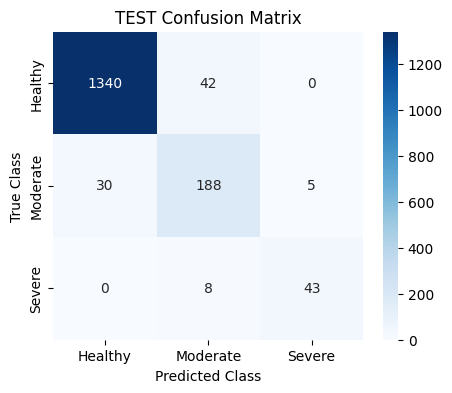


===== AUTOTEST ENSEMBLE RESULTS =====
Accuracy:  95.60943643512451
              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98      1282
    Moderate       0.83      0.83      0.83       200
      Severe       0.89      0.91      0.90        44

    accuracy                           0.96      1526
   macro avg       0.90      0.91      0.90      1526
weighted avg       0.96      0.96      0.96      1526



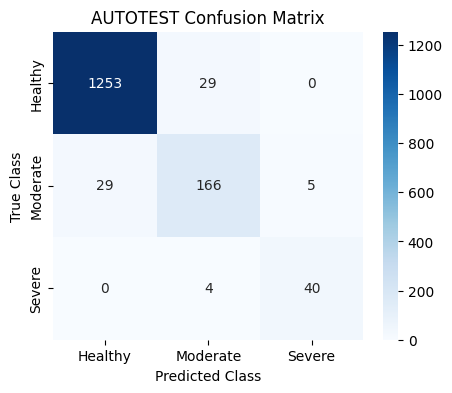

In [12]:
# ============================================================
# EVALUATION ON TEST & AUTOTEST SETS
# ============================================================
# Load best weights
try:
    cnn_model.load_state_dict(torch.load("cnn_model.pth", map_location=DEVICE))
    vit_model.load_state_dict(torch.load("vit_model.pth", map_location=DEVICE))
    dino_model.load_state_dict(torch.load("dino_model.pth", map_location=DEVICE))
    hybrid_model.load_state_dict(torch.load("hybrid_model.pth", map_location=DEVICE))
    print("Loaded best weights for all models.")
except FileNotFoundError as e:
    print(f"Warning: Could not load some weights. Proceeding with current memory weights. Error: {e}")

for name, ds in [("TEST", test_ds), ("AUTOTEST", auto_ds)]:
    # Compute TTA probabilities
    cnn_p = tta_predict(cnn_model, ds)
    vit_p = tta_predict(vit_model, ds)
    dino_p = tta_predict(dino_model, ds)
    hyb_p = tta_predict(hybrid_model, ds)

    # Ensemble Voting
    final_p = (cnn_p + vit_p + dino_p + hyb_p) / 4
    y_pred = np.argmax(final_p, axis=1)
    
    # Extract ground truth labels safely
    y_true = [y for _, y in ds]

    print(f"\n===== {name} ENSEMBLE RESULTS =====")
    print("Accuracy: ", accuracy_score(y_true, y_pred) * 100)
    print(classification_report(y_true, y_pred, target_names=FINAL_CLASSES))

    # Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True, fmt="d", cmap="Blues",
                xticklabels=FINAL_CLASSES,
                yticklabels=FINAL_CLASSES)
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.show()


>>> Loading best weights for individual evaluation...


C:\Users\setty\AppData\Local\Temp\ipykernel_7816\3835858682.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict[name].load_state_dict(torch.load(pth, map_locati

  Successfully loaded weights for ResNet50 (CNN)
  Successfully loaded weights for Vision Transformer (ViT)
  Successfully loaded weights for DINO ViT
  Successfully loaded weights for Combined Hybrid Model

==================== EVALUATING: ResNet50 (CNN) ====================
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.97      1382
    Moderate       0.76      0.85      0.80       223
      Severe       0.93      0.75      0.83        51

    accuracy                           0.94      1656
   macro avg       0.89      0.85      0.87      1656
weighted avg       0.95      0.94      0.94      1656


==================== EVALUATING: Vision Transformer (ViT) ====================
              precision    recall  f1-score   support

     Healthy       0.97      0.95      0.96      1382
    Moderate       0.71      0.78      0.75       223
      Severe       0.80      0.84      0.82        51

    accuracy                           0.93 

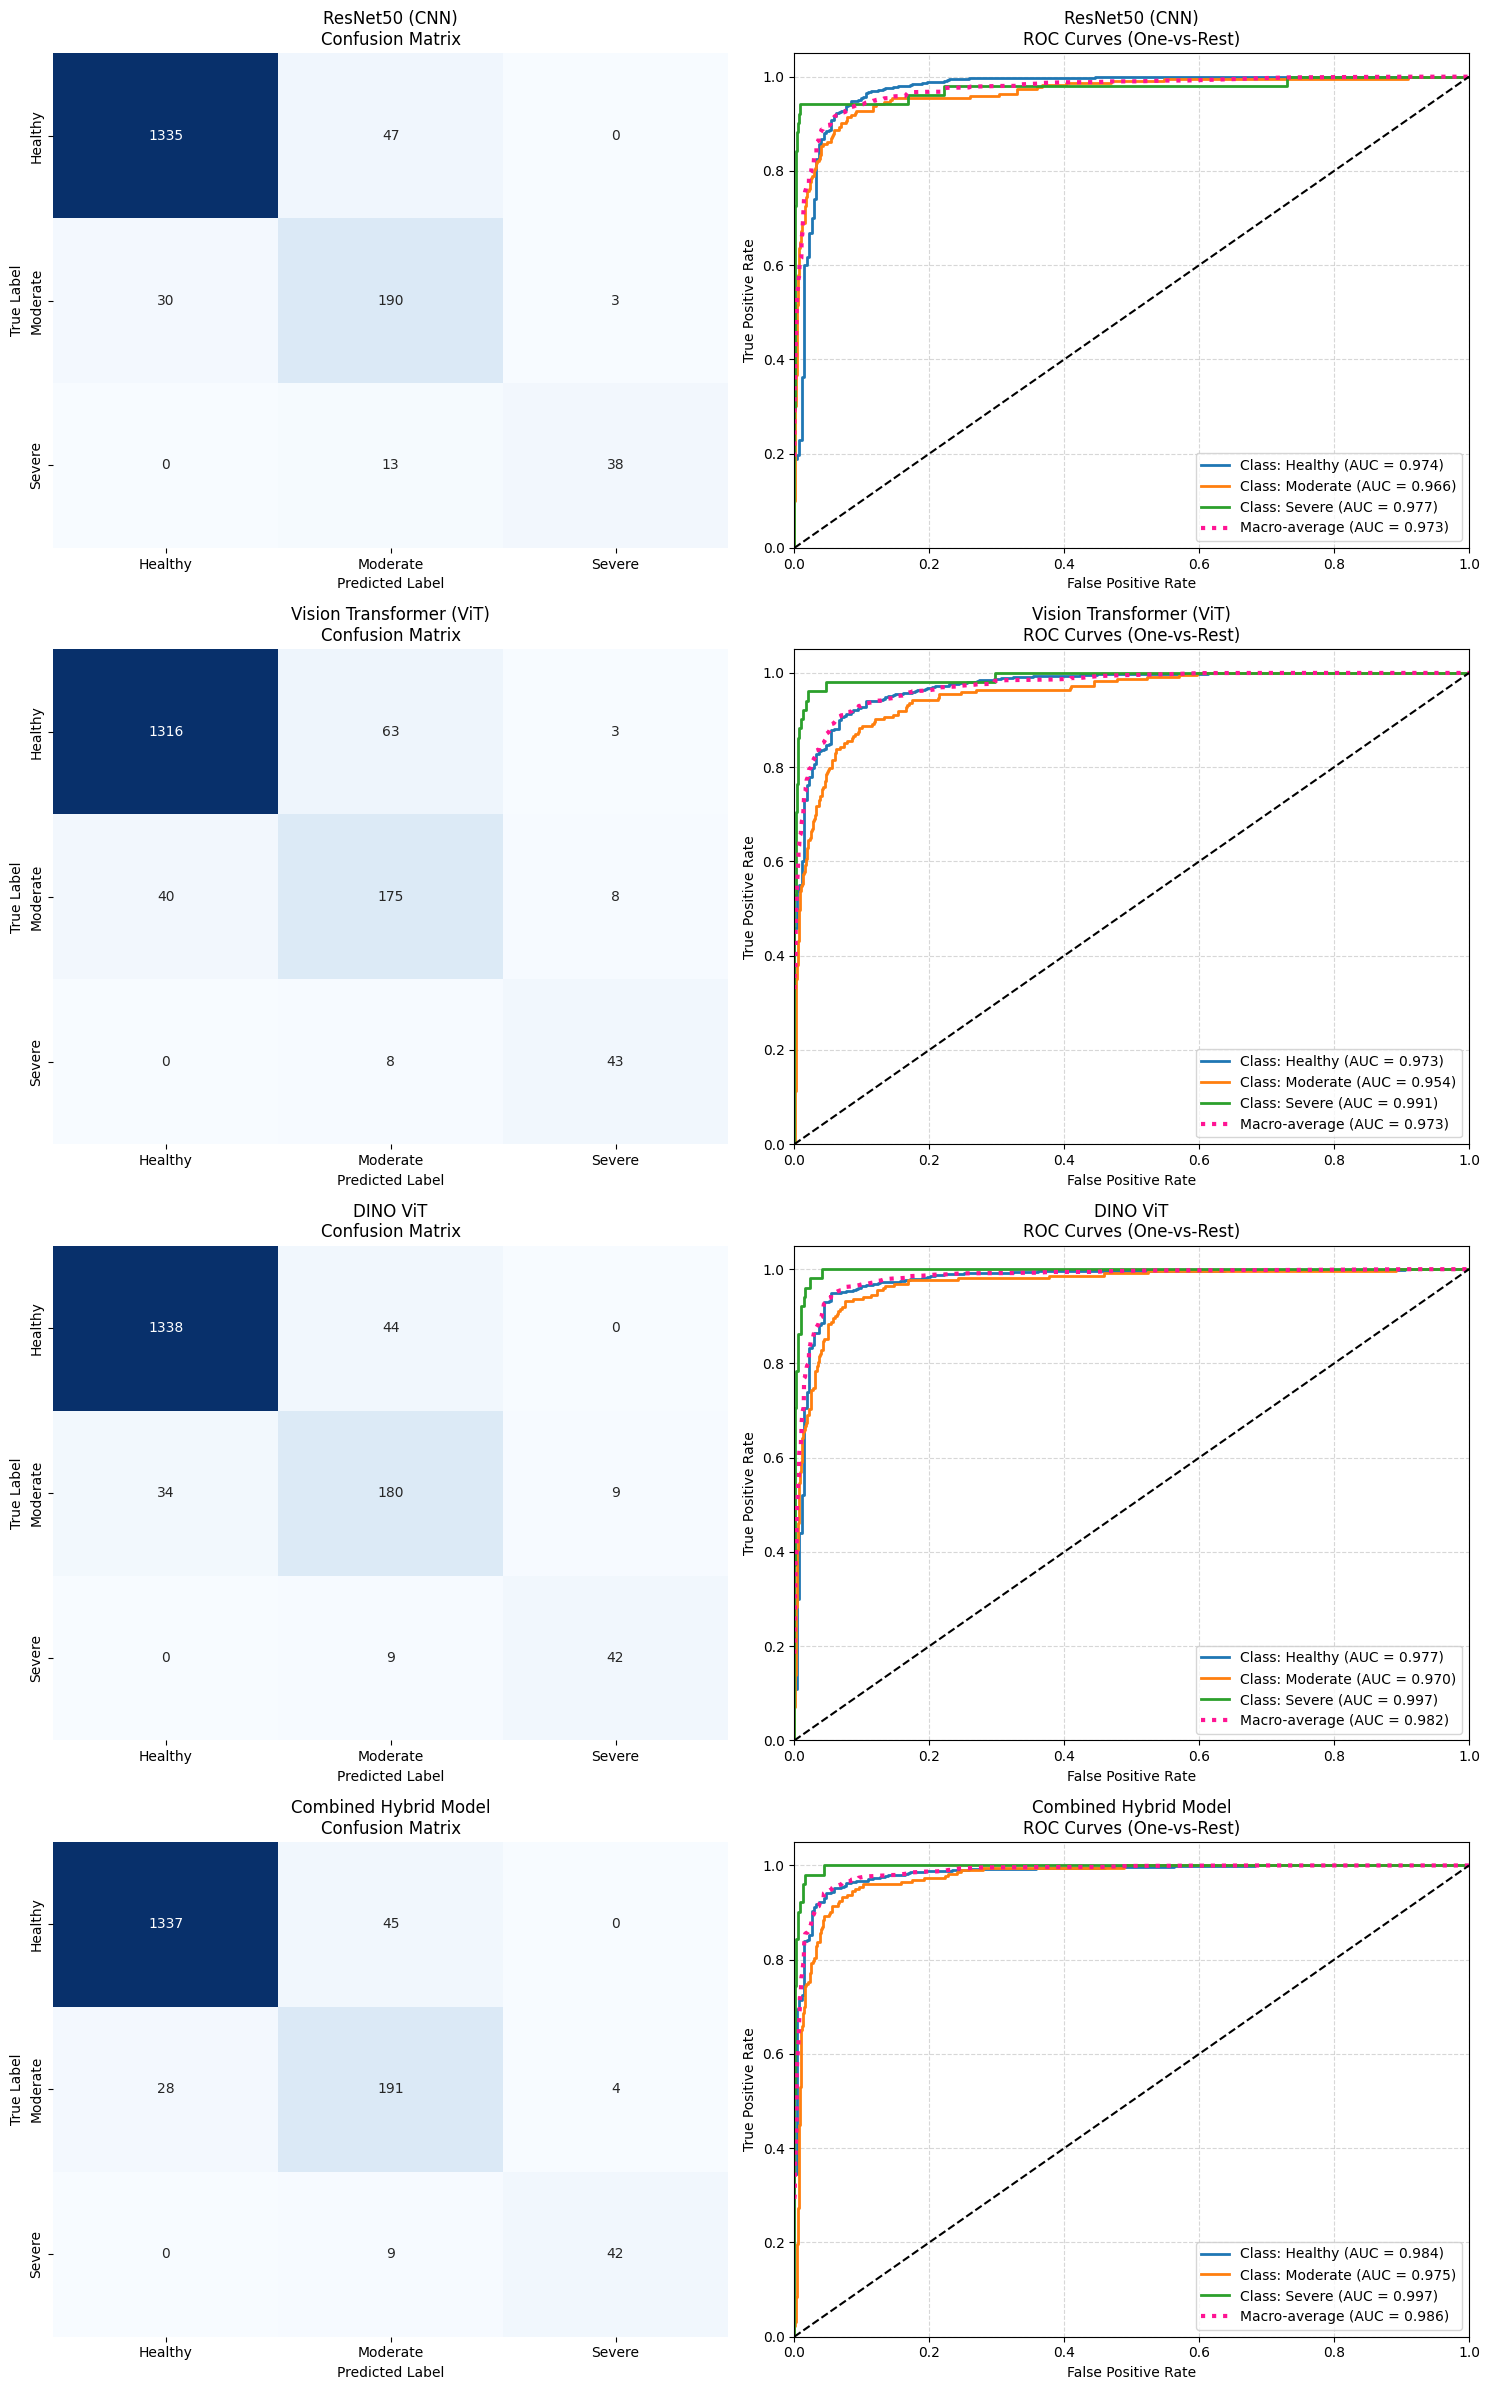

In [17]:
# ============================================================
# DETAILED INDIVIDUAL EVALUATION (REPORT, CONFUSION MATRIX, ROC-AUC)
# ============================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

# Ensure all models are in eval mode on GPU
models_dict = {
    "ResNet50 (CNN)": cnn_model.eval().to(DEVICE),
    "Vision Transformer (ViT)": vit_model.eval().to(DEVICE),
    "DINO ViT": dino_model.eval().to(DEVICE),
    "Combined Hybrid Model": hybrid_model.eval().to(DEVICE)
}

# 1. Load the best weights
print(">>> Loading best weights for individual evaluation...")
for name, pth in [
    ("ResNet50 (CNN)", "cnn_model.pth"),
    ("Vision Transformer (ViT)", "vit_model.pth"),
    ("DINO ViT", "dino_model.pth"),
    ("Combined Hybrid Model", "hybrid_model.pth")
]:
    try:
        models_dict[name].load_state_dict(torch.load(pth, map_location=DEVICE), strict=False)
        print(f"  Successfully loaded weights for {name}")
    except FileNotFoundError:
        print(f"  Warning: {pth} not found. Using active memory weights for {name}.")

# Binarize labels for multiclass ROC curves (One-vs-Rest)
y_true = np.array([y for _, y in test_ds])
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Set up matplotlib figure grid (4 rows: one row per model)
fig, axes = plt.subplots(4, 2, figsize=(15, 24))

for idx, (model_name, model) in enumerate(models_dict.items()):
    print(f"\n==================== EVALUATING: {model_name} ====================")
    
    # 2. Get Test-Time Augmentation (TTA) probabilities
    probs = tta_predict(model, test_ds)
    preds = np.argmax(probs, axis=1)
    
    # 3. Print Classification Report to console
    print(classification_report(y_true, preds, target_names=FINAL_CLASSES))
    
    # 4. Plot Confusion Matrix (Left Column)
    ax_cm = axes[idx, 0]
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=FINAL_CLASSES, yticklabels=FINAL_CLASSES, ax=ax_cm, cbar=False)
    ax_cm.set_title(f"{model_name}\nConfusion Matrix")
    ax_cm.set_ylabel("True Label")
    ax_cm.set_xlabel("Predicted Label")
    
    # 5. Compute and Plot ROC Curves (Right Column)
    ax_roc = axes[idx, 1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Professional color palette
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax_roc.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                    label=f'Class: {FINAL_CLASSES[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Compute Macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)
    
    ax_roc.plot(all_fpr, mean_tpr, color='deeppink', linestyle=':', lw=3,
                label=f'Macro-average (AUC = {macro_auc:.3f})')
    
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5) # Diagonal reference line
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f"{model_name}\nROC Curves (One-vs-Rest)")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


>>> Loading best weights for individual evaluation...


C:\Users\setty\AppData\Local\Temp\ipykernel_7816\3656433516.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict[name].load_state_dict(torch.load(pth, map_locati

  Successfully loaded weights for ResNet50 (CNN)
  Successfully loaded weights for Vision Transformer (ViT)
  Successfully loaded weights for DINO ViT
  Successfully loaded weights for Combined Hybrid Model

==================== EVALUATING: ResNet50 (CNN) ====================
Accuracy:  94.38405797101449
Precision (Macro): 88.82837487715535
Recall (Macro): 85.43690977891333
F1-Score (Macro): 86.7146347185423

  Class: Healthy
    Precision: 97.8021978021978
    Recall:    96.59913169319826
    F1-Score:  97.19694211867493

  Class: Moderate
    Precision: 76.0
    Recall:    85.20179372197309
    F1-Score:  80.33826638477801

  Class: Severe
    Precision: 92.6829268292683
    Recall:    74.50980392156863
    F1-Score:  82.6086956521739

==================== EVALUATING: Vision Transformer (ViT) ====================
Accuracy:  92.6328502415459
Precision (Macro): 82.60599616812293
Recall (Macro): 86.00445813450489
F1-Score (Macro): 84.22006285660984

  Class: Healthy
    Precision: 97.05

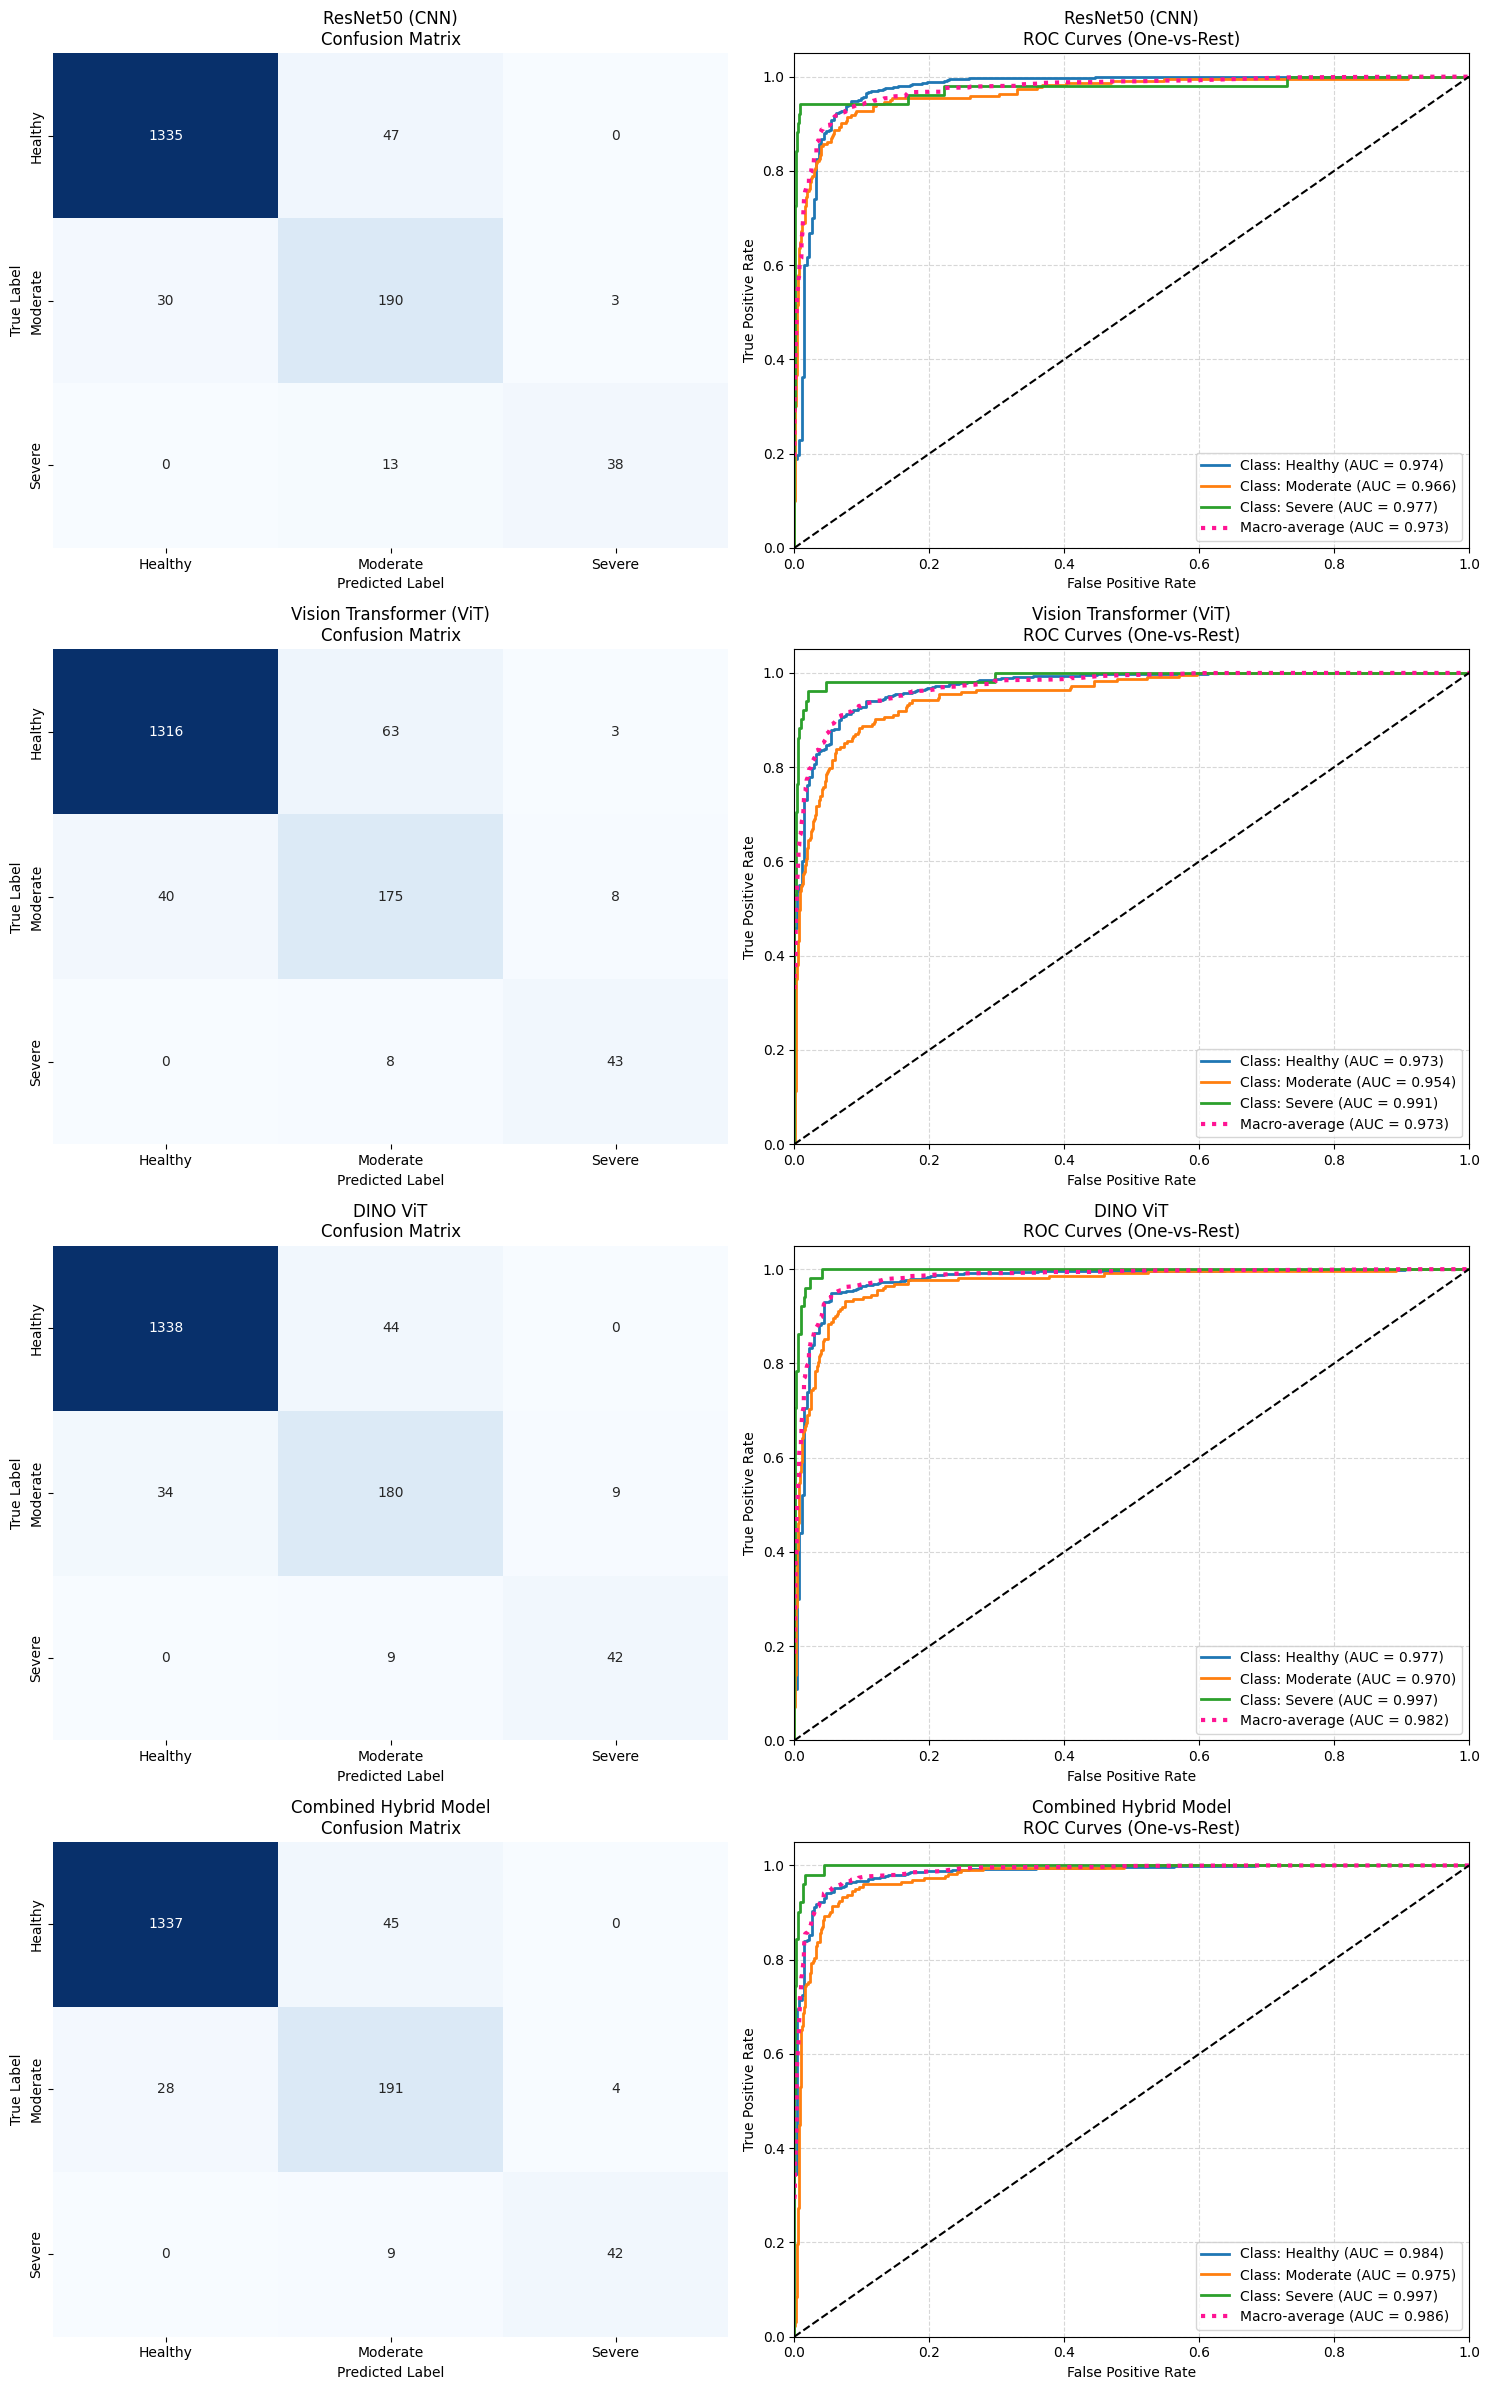

In [22]:
# ============================================================
# DETAILED INDIVIDUAL EVALUATION (REPORT, CONFUSION MATRIX, ROC-AUC)
# ============================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, confusion_matrix, precision_recall_fscore_support
)

# Ensure all models are in eval mode on GPU
models_dict = {
    "ResNet50 (CNN)": cnn_model.eval().to(DEVICE),
    "Vision Transformer (ViT)": vit_model.eval().to(DEVICE),
    "DINO ViT": dino_model.eval().to(DEVICE),
    "Combined Hybrid Model": hybrid_model.eval().to(DEVICE)
}

# 1. Load the best weights
print(">>> Loading best weights for individual evaluation...")
for name, pth in [
    ("ResNet50 (CNN)", "cnn_model.pth"),
    ("Vision Transformer (ViT)", "vit_model.pth"),
    ("DINO ViT", "dino_model.pth"),
    ("Combined Hybrid Model", "hybrid_model.pth")
]:
    try:
        models_dict[name].load_state_dict(torch.load(pth, map_location=DEVICE), strict=False)
        print(f"  Successfully loaded weights for {name}")
    except FileNotFoundError:
        print(f"  Warning: {pth} not found. Using active memory weights for {name}.")

# Binarize labels for multiclass ROC curves (One-vs-Rest)
y_true = np.array([y for _, y in test_ds])
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Set up matplotlib figure grid (4 rows: one row per model)
fig, axes = plt.subplots(4, 2, figsize=(15, 24))

for idx, (model_name, model) in enumerate(models_dict.items()):
    print(f"\n==================== EVALUATING: {model_name} ====================")
    
    # 2. Get Test-Time Augmentation (TTA) probabilities
    probs = tta_predict(model, test_ds)
    preds = np.argmax(probs, axis=1)
    
    # 3. Compute and print the raw, unrounded performance metrics
    acc = accuracy_score(y_true, preds) * 100
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, preds, average='macro')
    
    print(f"Accuracy:  {acc}")
    print(f"Precision (Macro): {prec_macro * 100}")
    print(f"Recall (Macro): {rec_macro * 100}")
    print(f"F1-Score (Macro): {f1_macro * 100}")
    
    # Class-specific raw metrics
    prec_class, rec_class, f1_class, _ = precision_recall_fscore_support(y_true, preds, average=None)
    for i, cls_name in enumerate(FINAL_CLASSES):
        print(f"\n  Class: {cls_name}")
        print(f"    Precision: {prec_class[i] * 100}")
        print(f"    Recall:    {rec_class[i] * 100}")
        print(f"    F1-Score:  {f1_class[i] * 100}")
    
    # 4. Plot Confusion Matrix (Left Column)
    ax_cm = axes[idx, 0]
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=FINAL_CLASSES, yticklabels=FINAL_CLASSES, ax=ax_cm, cbar=False)
    ax_cm.set_title(f"{model_name}\nConfusion Matrix")
    ax_cm.set_ylabel("True Label")
    ax_cm.set_xlabel("Predicted Label")
    
    # 5. Compute and Plot ROC Curves (Right Column)
    ax_roc = axes[idx, 1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax_roc.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                    label=f'Class: {FINAL_CLASSES[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Compute Macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)
    
    ax_roc.plot(all_fpr, mean_tpr, color='deeppink', linestyle=':', lw=3,
                label=f'Macro-average (AUC = {macro_auc:.3f})')
    
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f"{model_name}\nROC Curves (One-vs-Rest)")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


>>> Loading best weights for individual evaluation...


C:\Users\setty\AppData\Local\Temp\ipykernel_7816\304913956.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models_dict[name].load_state_dict(torch.load(pth, map_locatio

  Successfully loaded weights for ResNet50 (CNN)
  Successfully loaded weights for Vision Transformer (ViT)
  Successfully loaded weights for DINO ViT
  Successfully loaded weights for Combined Hybrid Model


############################################################
  EVALUATING ON DATASET: TEST  (Size: 1656)
############################################################

----- TEST | ResNet50 (CNN) -----
Accuracy:  94.38405797101449
Precision (Macro): 88.82837487715535
Recall (Macro): 85.43690977891333
F1-Score (Macro): 86.7146347185423

  Class: Healthy
    Precision: 97.8021978021978
    Recall:    96.59913169319826
    F1-Score:  97.19694211867493

  Class: Moderate
    Precision: 76.0
    Recall:    85.20179372197309
    F1-Score:  80.33826638477801

  Class: Severe
    Precision: 92.6829268292683
    Recall:    74.50980392156863
    F1-Score:  82.6086956521739

----- TEST | Vision Transformer (ViT) -----
Accuracy:  92.6328502415459
Precision (Macro): 82.60599616812293
Recall (Ma

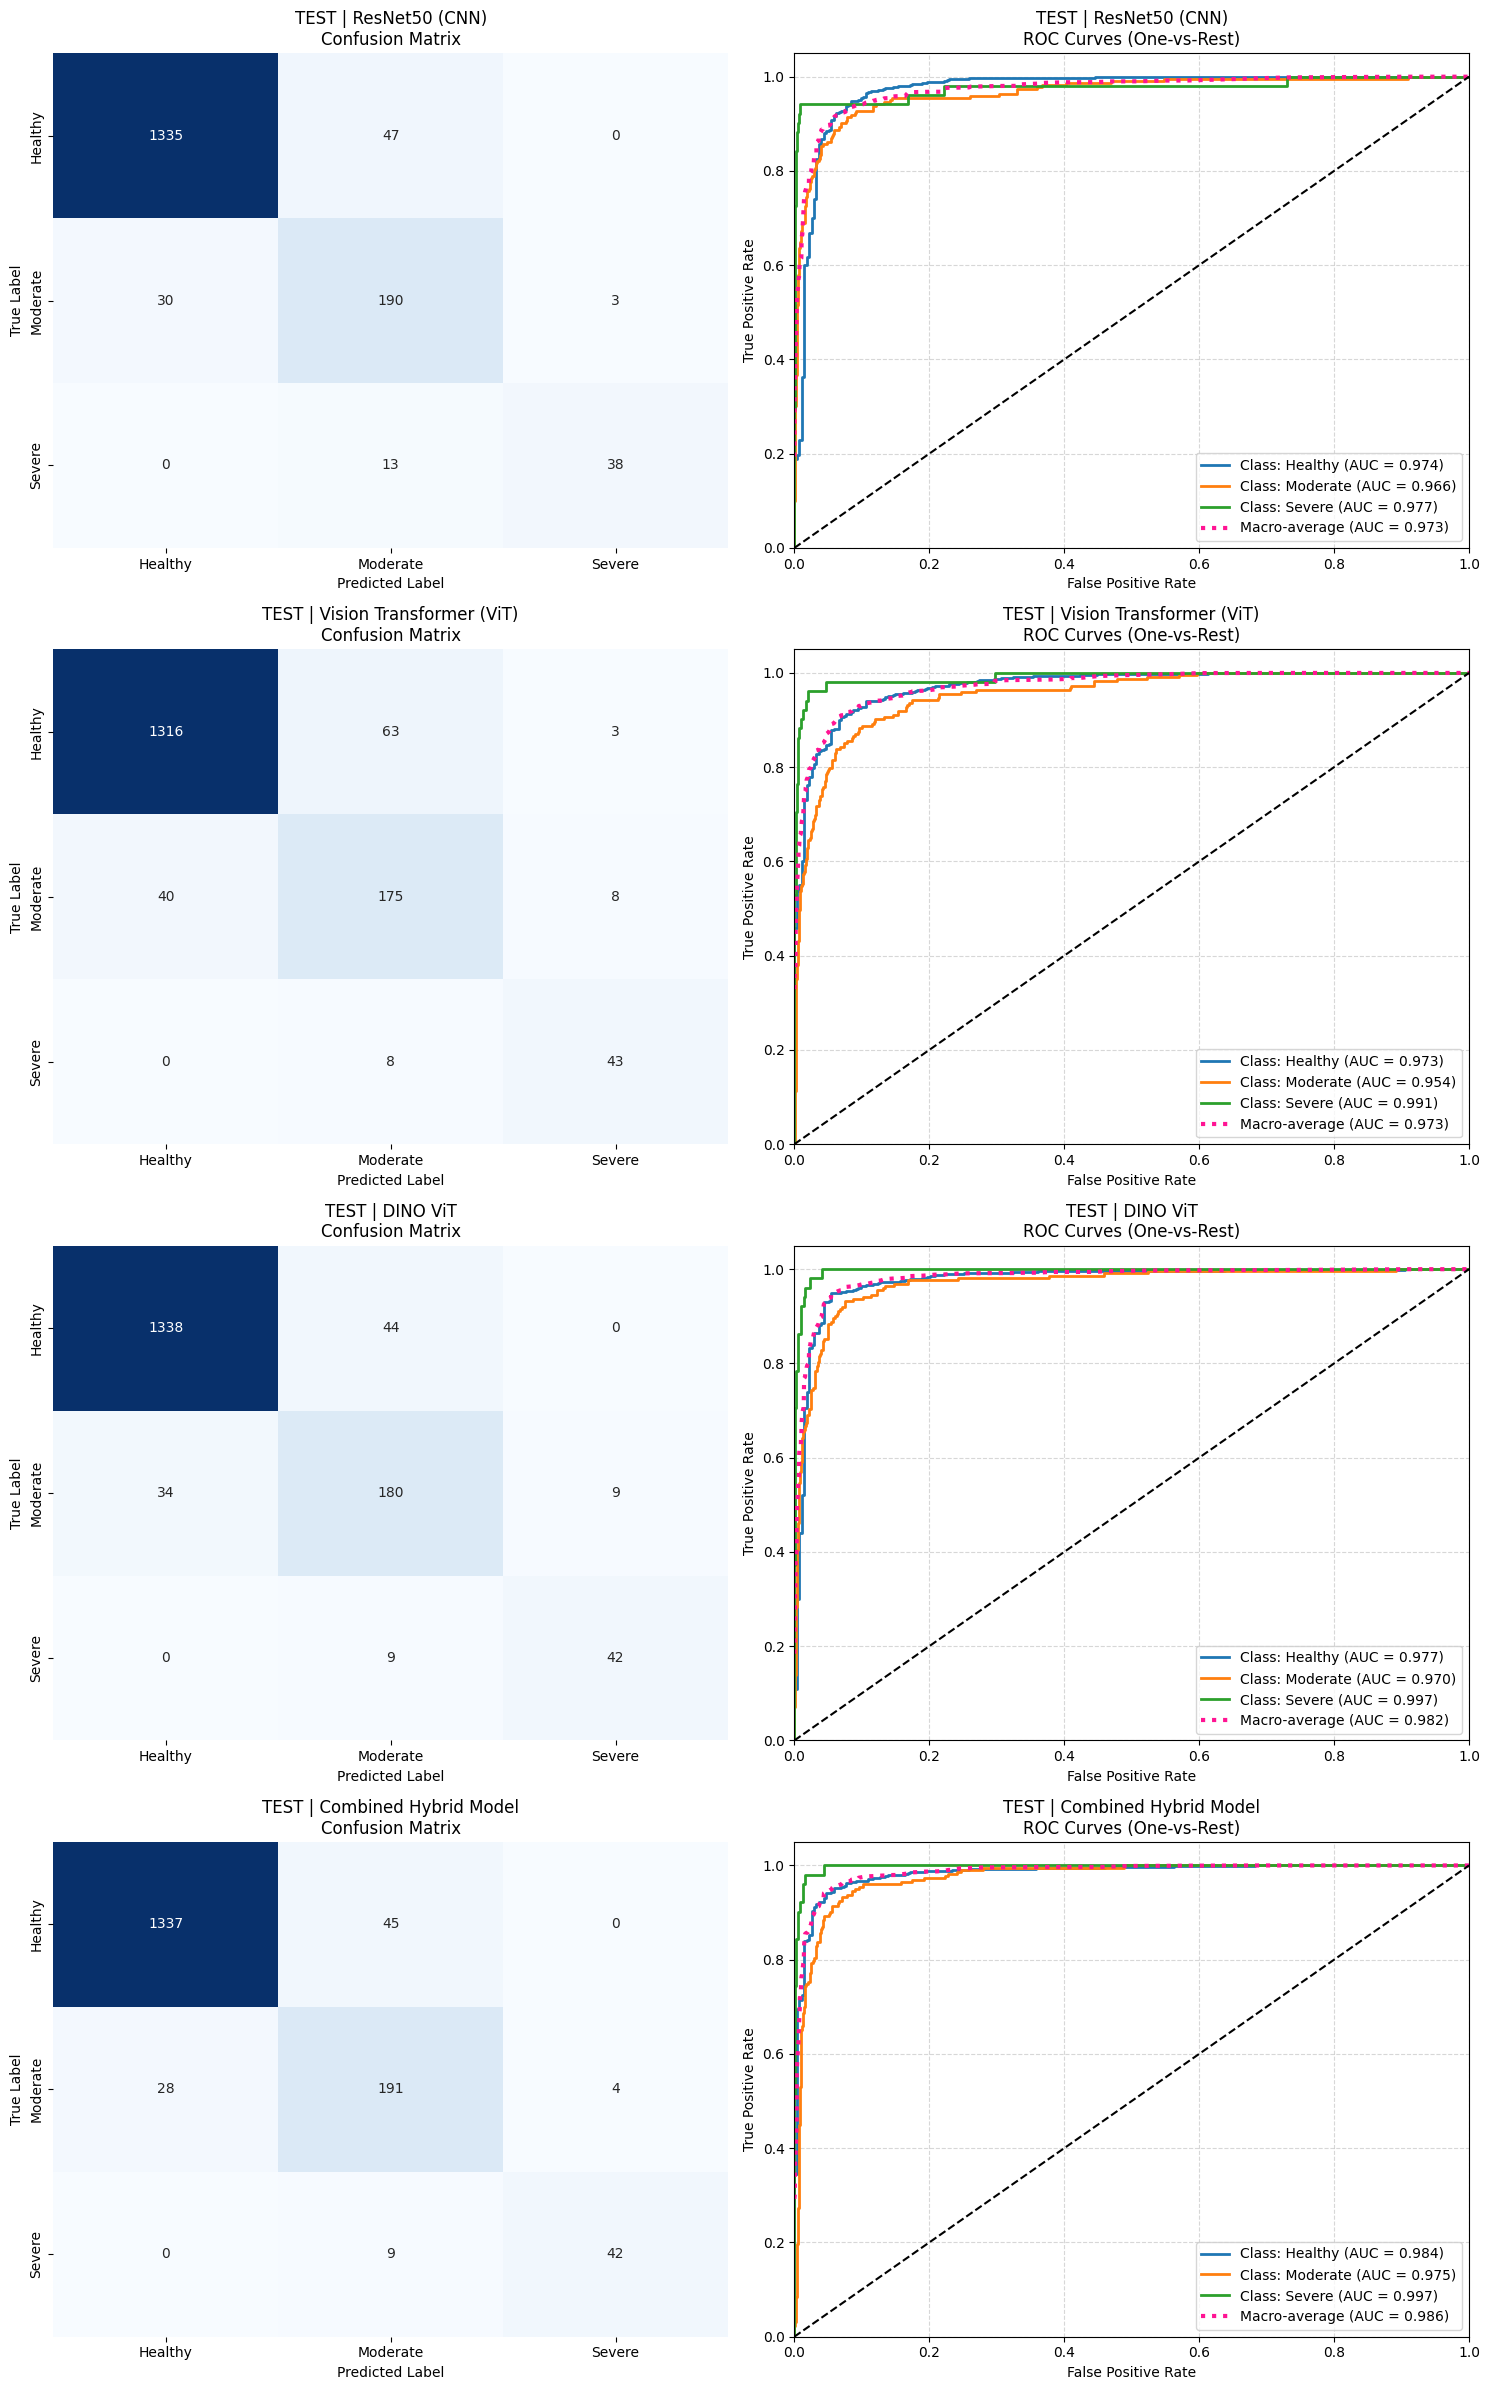



############################################################
  EVALUATING ON DATASET: AUTOTEST  (Size: 1526)
############################################################

----- AUTOTEST | ResNet50 (CNN) -----
Accuracy:  94.56094364351245
Precision (Macro): 88.9597910082391
Recall (Macro): 86.47510991348744
F1-Score (Macro): 87.52899622929692

  Class: Healthy
    Precision: 97.56480754124117
    Recall:    96.8798751950078
    F1-Score:  97.22113502935422

  Class: Moderate
    Precision: 77.20930232558139
    Recall:    83.0
    F1-Score:  80.0

  Class: Severe
    Precision: 92.10526315789474
    Recall:    79.54545454545455
    F1-Score:  85.36585365853658

----- AUTOTEST | Vision Transformer (ViT) -----
Accuracy:  92.85714285714286
Precision (Macro): 81.5772281451343
Recall (Macro): 82.70443908665438
F1-Score (Macro): 82.10902160249518

  Class: Healthy
    Precision: 96.41744548286604
    Recall:    96.56786271450858
    F1-Score:  96.49259547934528

  Class: Moderate
    Precis

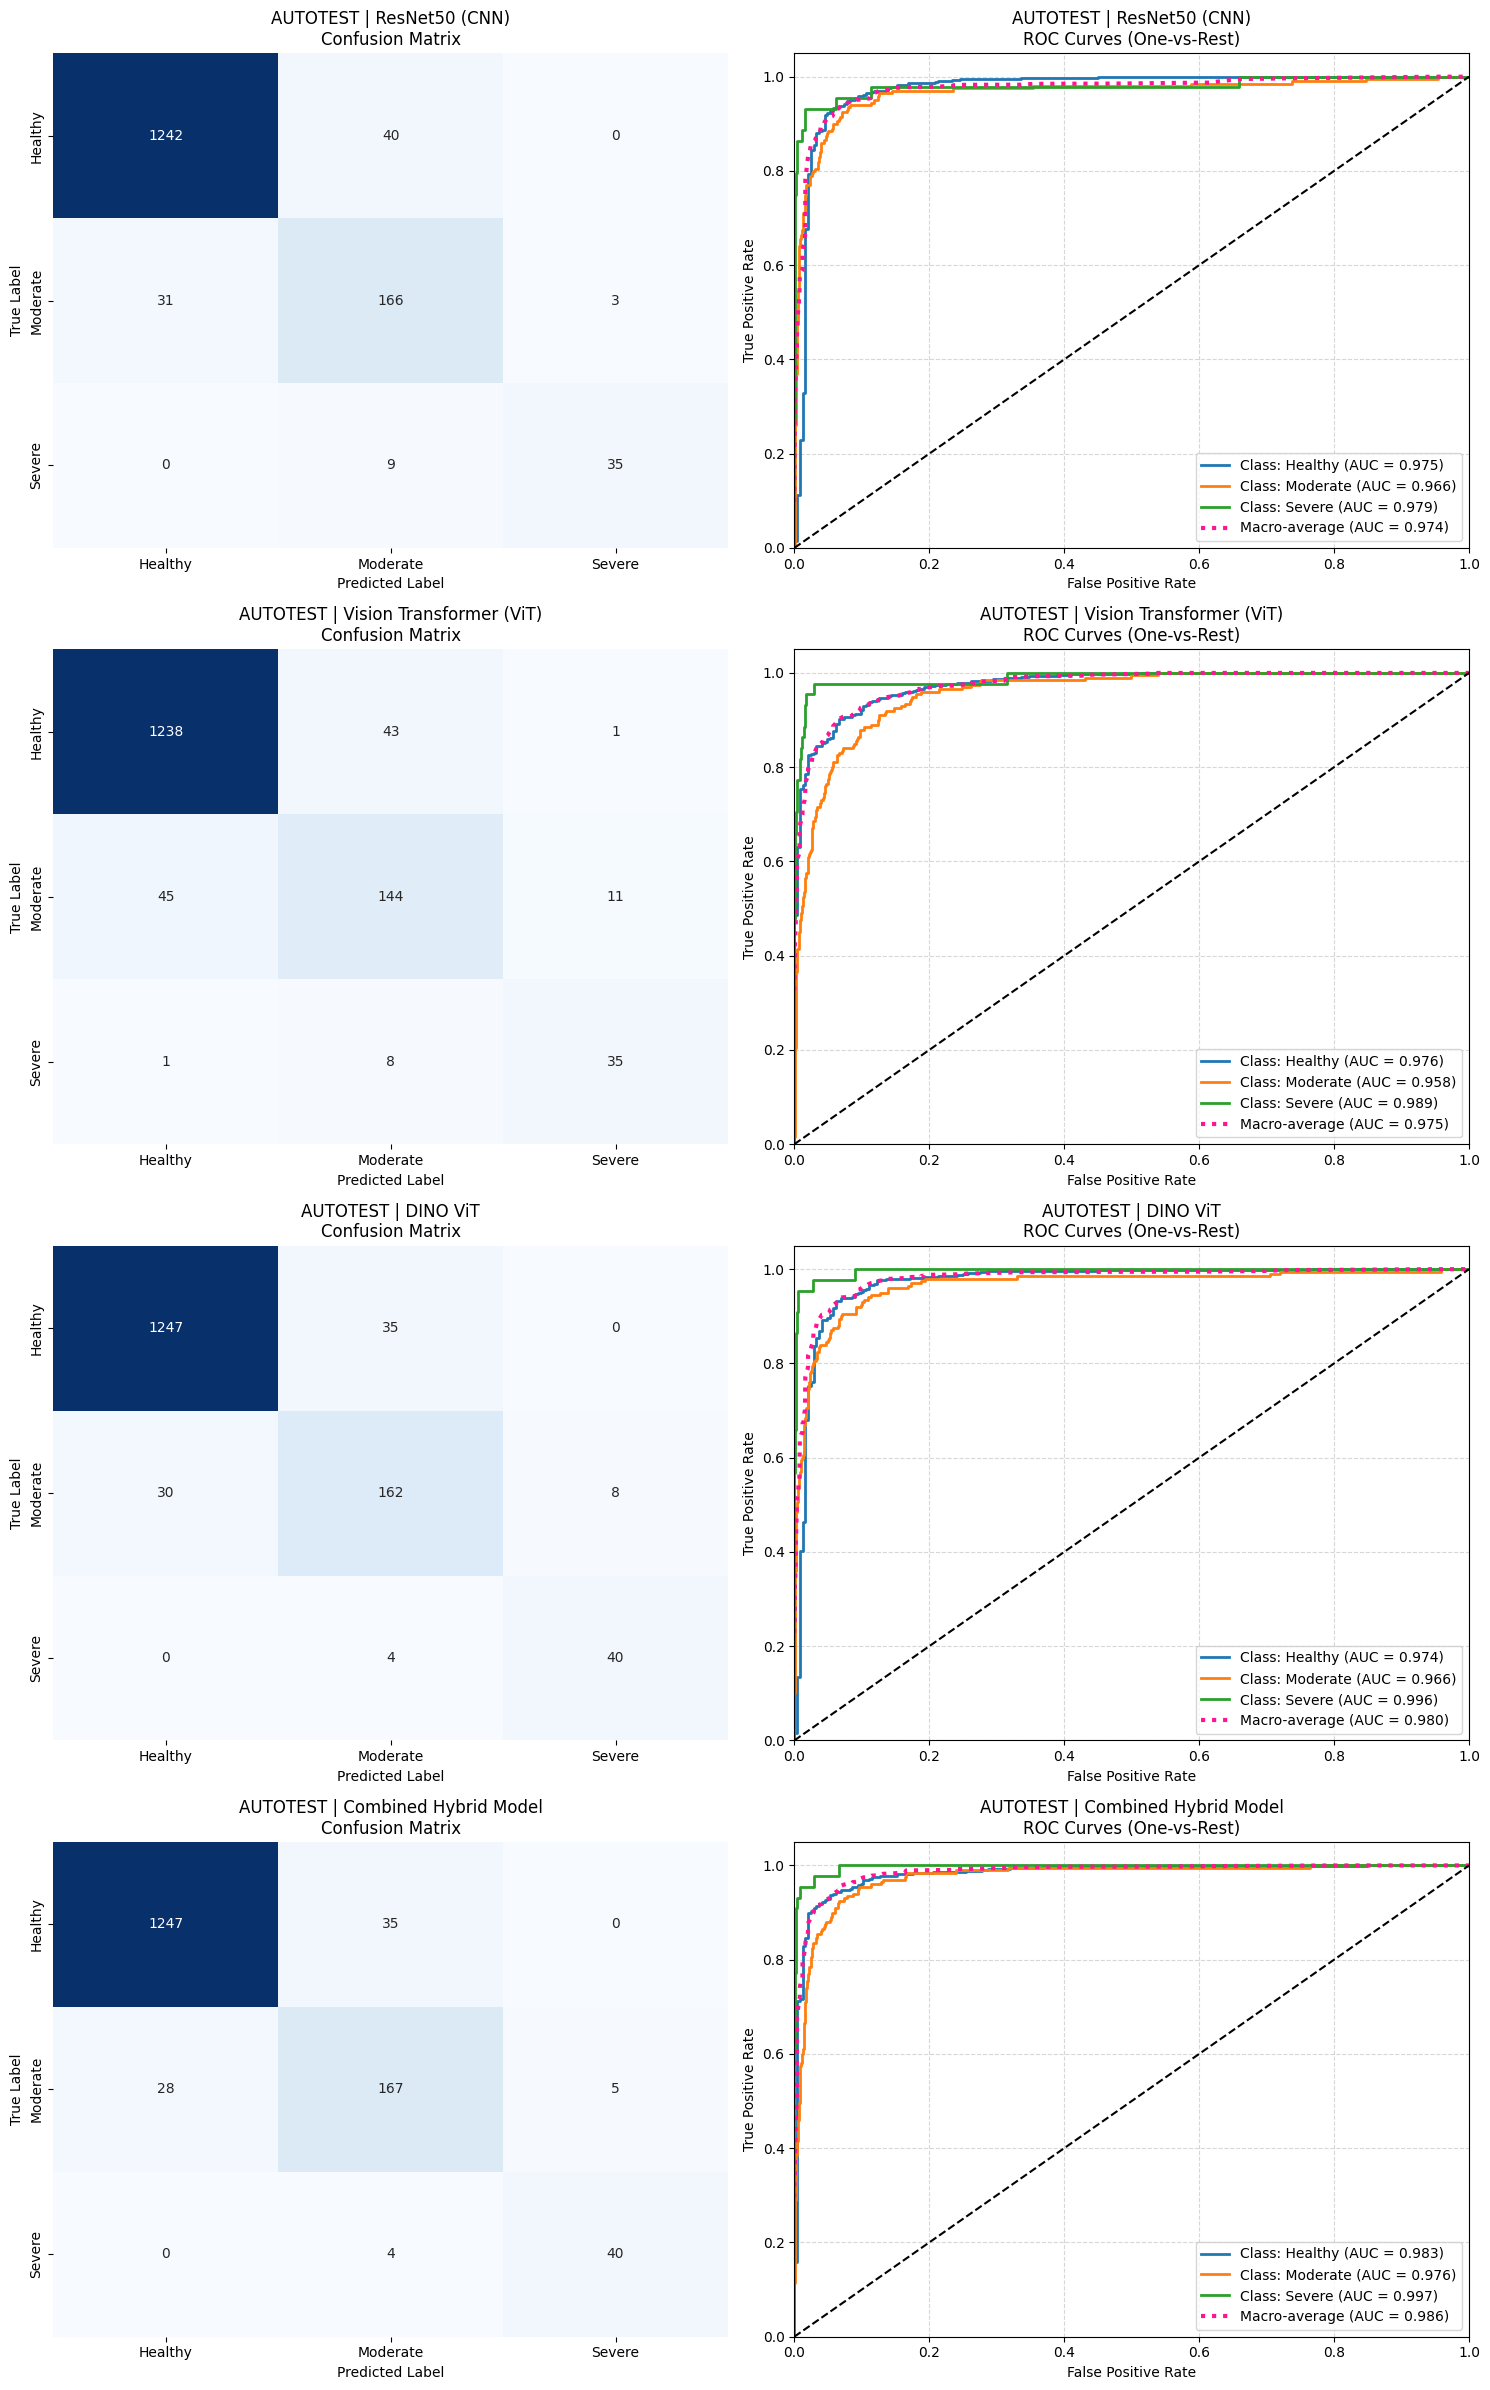

In [23]:
# ============================================================
# DETAILED INDIVIDUAL EVALUATION ON TEST & AUTOTEST DATASETS
# ============================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, confusion_matrix, precision_recall_fscore_support
)

# Ensure all models are in eval mode on GPU
models_dict = {
    "ResNet50 (CNN)": cnn_model.eval().to(DEVICE),
    "Vision Transformer (ViT)": vit_model.eval().to(DEVICE),
    "DINO ViT": dino_model.eval().to(DEVICE),
    "Combined Hybrid Model": hybrid_model.eval().to(DEVICE)
}

# 1. Load the best weights
print(">>> Loading best weights for individual evaluation...")
for name, pth in [
    ("ResNet50 (CNN)", "cnn_model.pth"),
    ("Vision Transformer (ViT)", "vit_model.pth"),
    ("DINO ViT", "dino_model.pth"),
    ("Combined Hybrid Model", "hybrid_model.pth")
]:
    try:
        models_dict[name].load_state_dict(torch.load(pth, map_location=DEVICE), strict=False)
        print(f"  Successfully loaded weights for {name}")
    except FileNotFoundError:
        print(f"  Warning: {pth} not found. Using active memory weights for {name}.")

# 2. Loop through both TEST and AUTOTEST datasets
for dataset_name, ds in [("TEST", test_ds), ("AUTOTEST", auto_ds)]:
    print(f"\n\n" + "#" * 60)
    print(f"  EVALUATING ON DATASET: {dataset_name}  (Size: {len(ds)})")
    print("#" * 60)
    
    # Binarize labels for multiclass ROC curves (One-vs-Rest)
    y_true = np.array([y for _, y in ds])
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

    # Set up matplotlib figure grid (4 rows: one row per model)
    fig, axes = plt.subplots(4, 2, figsize=(15, 24))

    for idx, (model_name, model) in enumerate(models_dict.items()):
        print(f"\n----- {dataset_name} | {model_name} -----")
        
        # Get Test-Time Augmentation (TTA) probabilities
        probs = tta_predict(model, ds)
        preds = np.argmax(probs, axis=1)
        
        # Compute and print the raw, unrounded performance metrics
        acc = accuracy_score(y_true, preds) * 100
        prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, preds, average='macro')
        
        print(f"Accuracy:  {acc}")
        print(f"Precision (Macro): {prec_macro * 100}")
        print(f"Recall (Macro): {rec_macro * 100}")
        print(f"F1-Score (Macro): {f1_macro * 100}")
        
        # Class-specific raw metrics
        prec_class, rec_class, f1_class, _ = precision_recall_fscore_support(y_true, preds, average=None)
        for i, cls_name in enumerate(FINAL_CLASSES):
            print(f"\n  Class: {cls_name}")
            print(f"    Precision: {prec_class[i] * 100}")
            print(f"    Recall:    {rec_class[i] * 100}")
            print(f"    F1-Score:  {f1_class[i] * 100}")
        
        # Plot Confusion Matrix (Left Column)
        ax_cm = axes[idx, 0]
        cm = confusion_matrix(y_true, preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                    xticklabels=FINAL_CLASSES, yticklabels=FINAL_CLASSES, ax=ax_cm, cbar=False)
        ax_cm.set_title(f"{dataset_name} | {model_name}\nConfusion Matrix")
        ax_cm.set_ylabel("True Label")
        ax_cm.set_xlabel("Predicted Label")
        
        # Compute and Plot ROC Curves (Right Column)
        ax_roc = axes[idx, 1]
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for i in range(NUM_CLASSES):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            ax_roc.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                        label=f'Class: {FINAL_CLASSES[i]} (AUC = {roc_auc[i]:.3f})')
        
        # Compute Macro-average ROC curve
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(NUM_CLASSES):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= NUM_CLASSES
        macro_auc = auc(all_fpr, mean_tpr)
        
        ax_roc.plot(all_fpr, mean_tpr, color='deeppink', linestyle=':', lw=3,
                    label=f'Macro-average (AUC = {macro_auc:.3f})')
        
        ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f"{dataset_name} | {model_name}\nROC Curves (One-vs-Rest)")
        ax_roc.legend(loc="lower right")
        ax_roc.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()



===== HYBRID BRANCH ATTRIBUTIONS FOR CLASS: Healthy =====


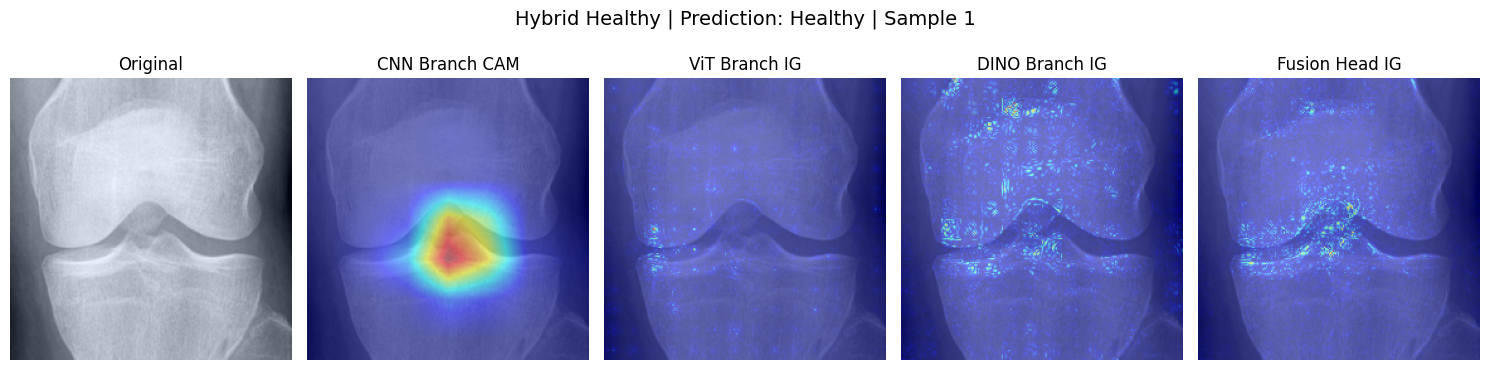

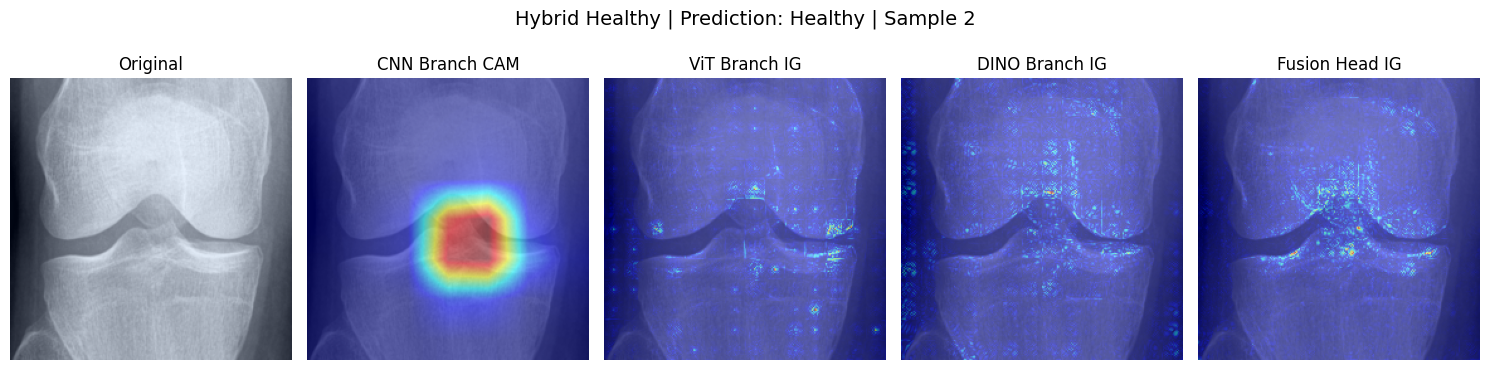

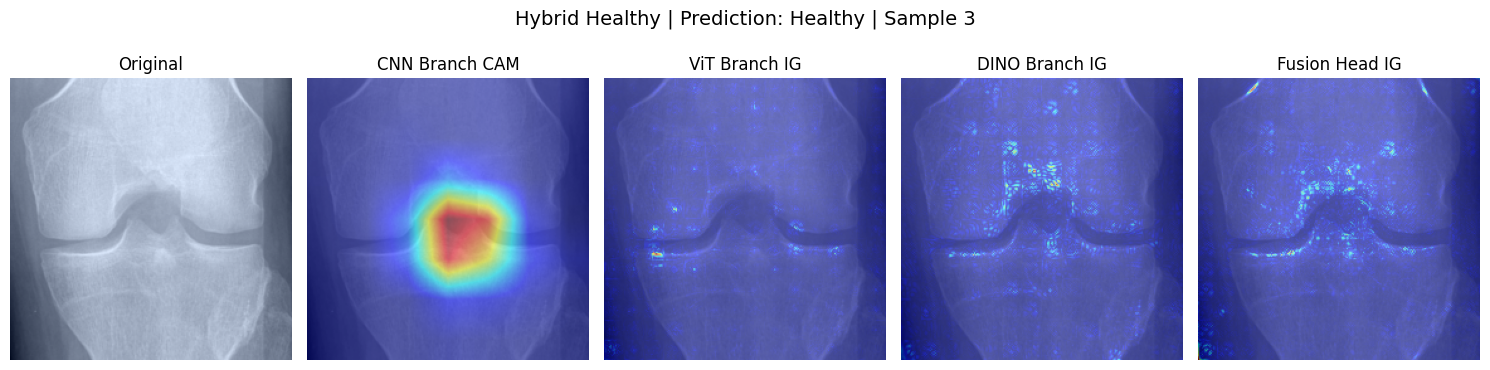


===== HYBRID BRANCH ATTRIBUTIONS FOR CLASS: Moderate =====


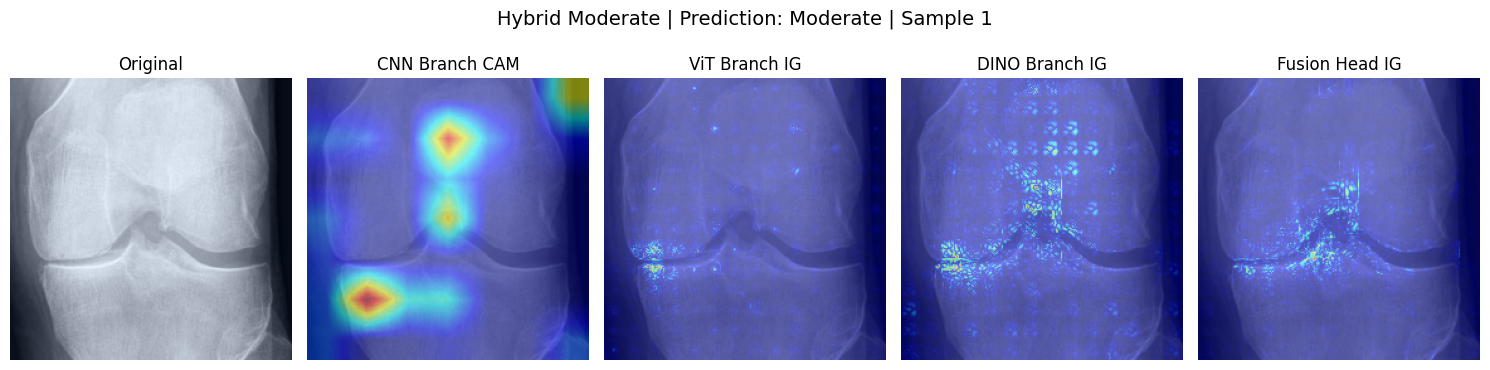

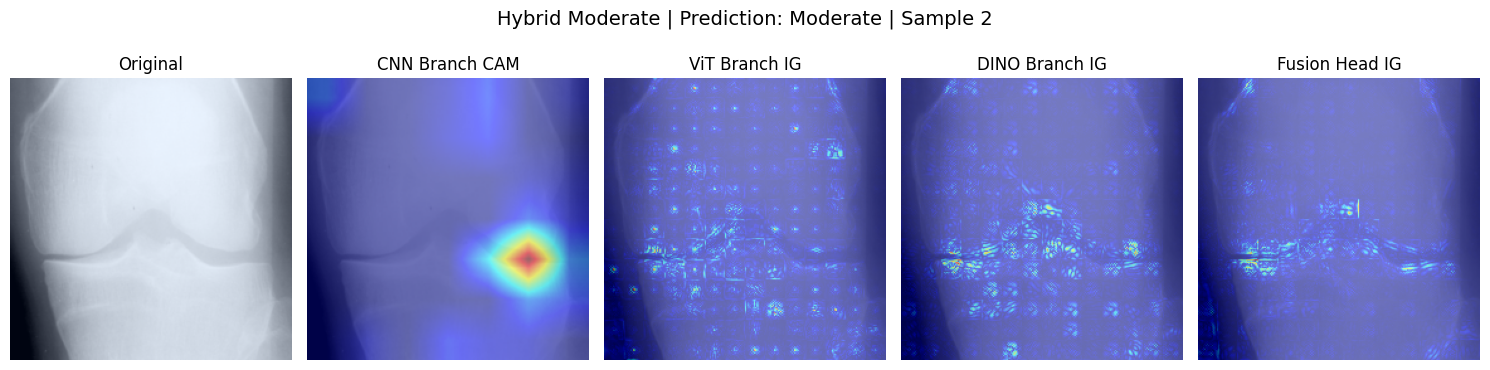

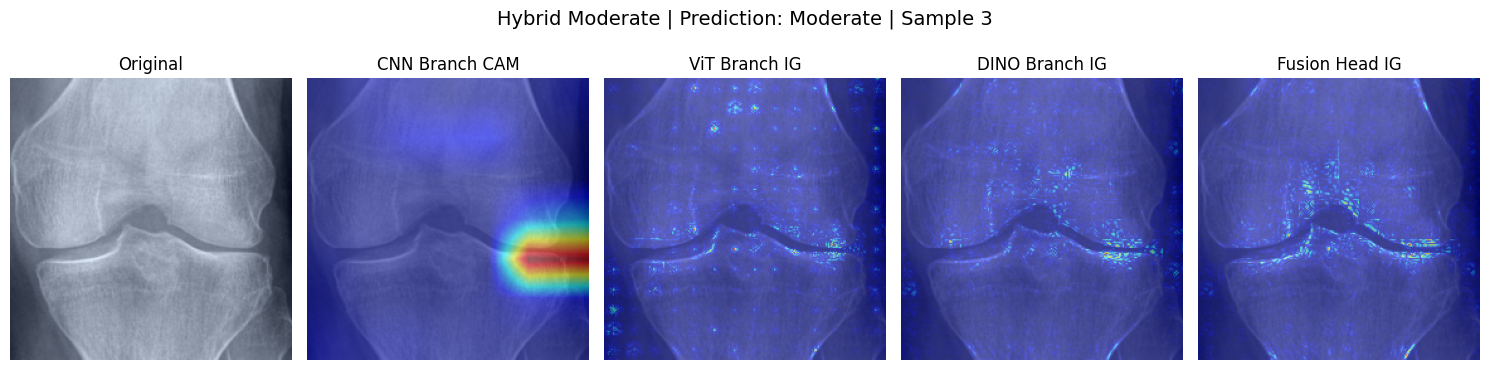


===== HYBRID BRANCH ATTRIBUTIONS FOR CLASS: Severe =====


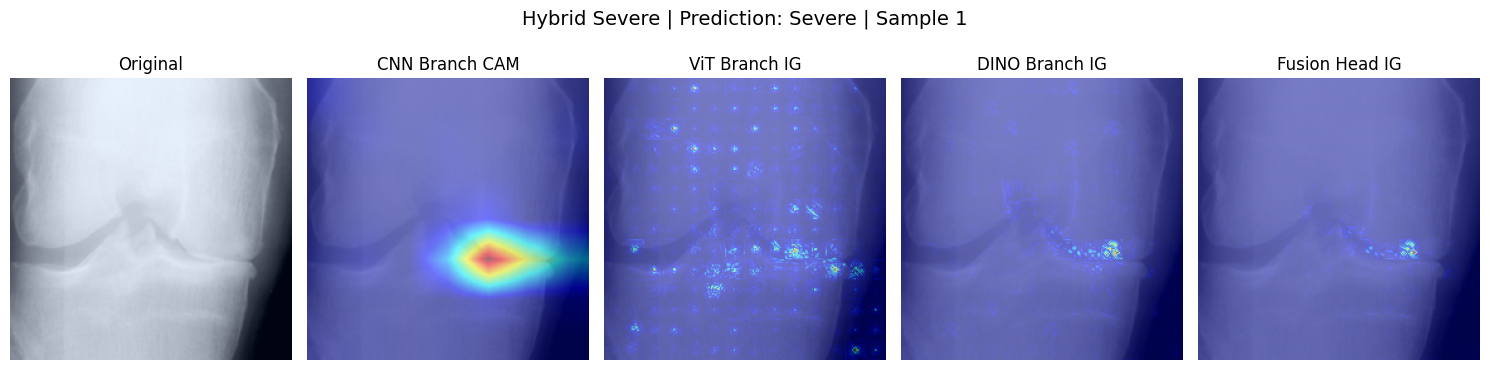

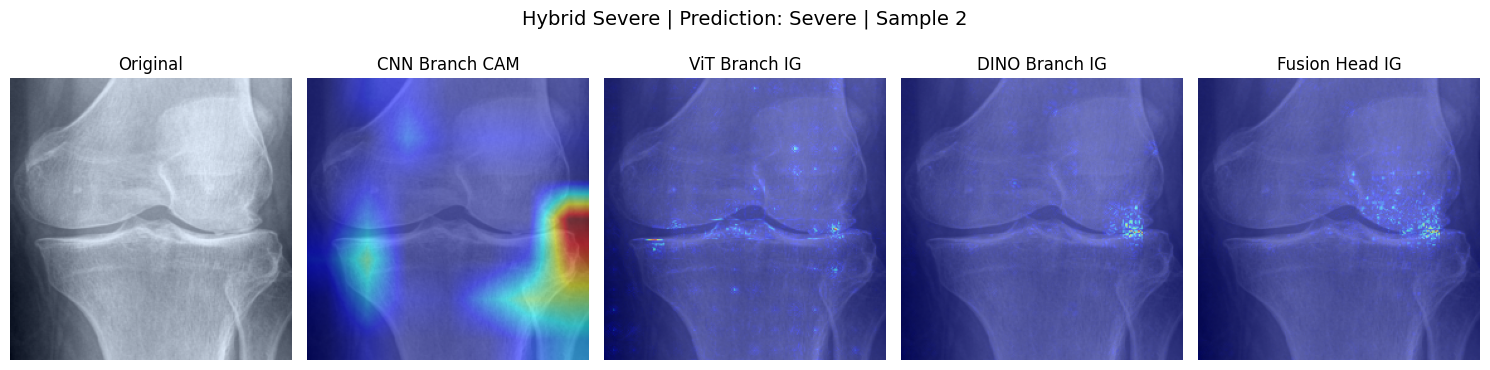

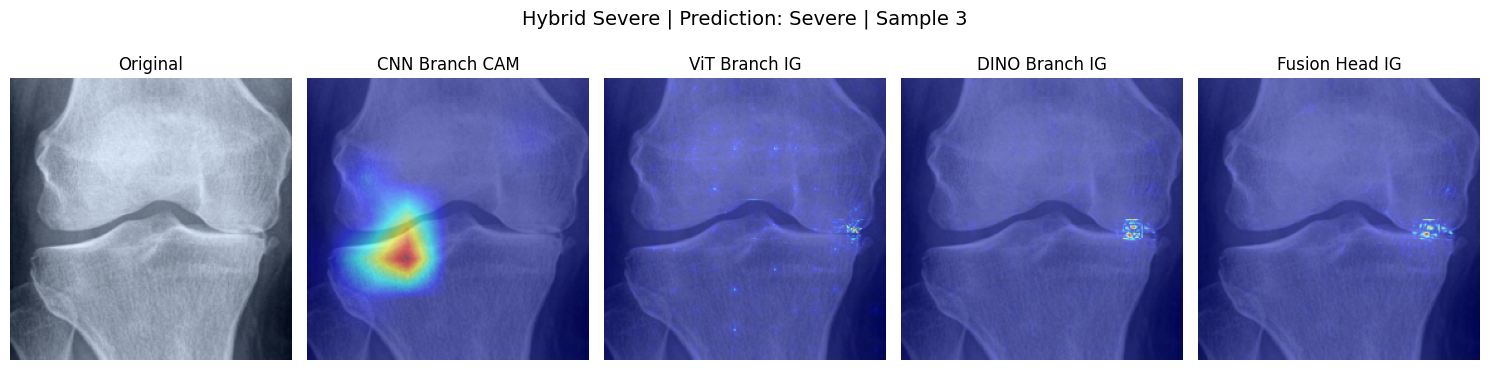

In [15]:
# ============================================================
# DYNAMIC HYBRID MODEL BRANCH ATTRIBUTION XAI
# Grad-CAM on CNN branch | Integrated Gradients on ViT, DINO & Fusion
# ============================================================
from captum.attr import IntegratedGradients

model = hybrid_model.eval().to(DEVICE)

# A simple wrapper to make the hybrid model return only logits, as expected by pytorch-grad-cam
class HybridModelLogitsWrapper(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
    def forward(self, x):
        out = self.base_model(x)
        if isinstance(out, tuple):
            return out[0]
        return out

wrapped_hybrid = HybridModelLogitsWrapper(model)

# Setup CNN-branch Grad-CAM wrapping the entire hybrid model (via the logits wrapper)
gradcam_hybrid = GradCAM(wrapped_hybrid, [wrapped_hybrid.base_model.cnn.layer4[-1]])

# Create wrapper functions returning scalar outputs for Captum attributions
# Integrated Gradients require a single target logit or scalar attribution value
ig_fusion = IntegratedGradients(lambda x: model(x)[0])
ig_vit    = IntegratedGradients(lambda x: model(x)[2].norm(dim=1))
ig_dino   = IntegratedGradients(lambda x: model(x)[3].norm(dim=1))

for cls in samples:
    print(f"\n===== HYBRID BRANCH ATTRIBUTIONS FOR CLASS: {FINAL_CLASSES[cls]} =====")
    
    for idx, (img, y, path) in enumerate(samples[cls]):
        x = img.unsqueeze(0).to(DEVICE)
        img_np = denorm(img)

        # Get prediction
        logits, _, _, _ = model(x)
        pred_cls = logits.argmax(1).item()

        # Compute Grad-CAM on CNN branch
        # The library automatically runs the backward pass on the highest logit (pred_cls)
        cnn_cam = gradcam_hybrid(x)[0]

        # Compute Branch-specific attributions
        vit_attr = ig_vit.attribute(x, n_steps=15)
        vit_map = vit_attr.abs().mean(1)[0].cpu().numpy()
        vit_map = (vit_map - vit_map.min()) / (vit_map.max() - vit_map.min() + 1e-8)

        dino_attr = ig_dino.attribute(x, n_steps=15)
        dino_map = dino_attr.abs().mean(1)[0].cpu().numpy()
        dino_map = (dino_map - dino_map.min()) / (dino_map.max() - dino_map.min() + 1e-8)

        fusion_attr = ig_fusion.attribute(x, target=pred_cls, n_steps=15)
        fusion_map = fusion_attr.abs().mean(1)[0].cpu().numpy()
        fusion_map = (fusion_map - fusion_map.min()) / (fusion_map.max() - fusion_map.min() + 1e-8)

        # Generate overlays
        vis_cnn = show_cam_on_image(img_np, cnn_cam, use_rgb=True)
        vis_vit = show_cam_on_image(img_np, vit_map, use_rgb=True)
        vis_dino = show_cam_on_image(img_np, dino_map, use_rgb=True)
        vis_fusion = show_cam_on_image(img_np, fusion_map, use_rgb=True)

        # Plot comparison row
        plt.figure(figsize=(15,4))
        titles = ["Original", "CNN Branch CAM", "ViT Branch IG", "DINO Branch IG", "Fusion Head IG"]
        imgs = [img_np, vis_cnn, vis_vit, vis_dino, vis_fusion]

        for i in range(5):
            plt.subplot(1, 5, i + 1)
            plt.imshow(imgs[i])
            plt.title(titles[i])
            plt.axis("off")

        plt.suptitle(f"Hybrid {FINAL_CLASSES[y]} | Prediction: {FINAL_CLASSES[pred_cls]} | Sample {idx+1}", fontsize=14)
        plt.tight_layout()
        plt.show()



LIME is already installed.

>>> Running LIME Explanation on Test Sample...


100%|██████████| 250/250 [00:03<00:00, 72.69it/s]


>>> Running Vanilla Saliency Map...


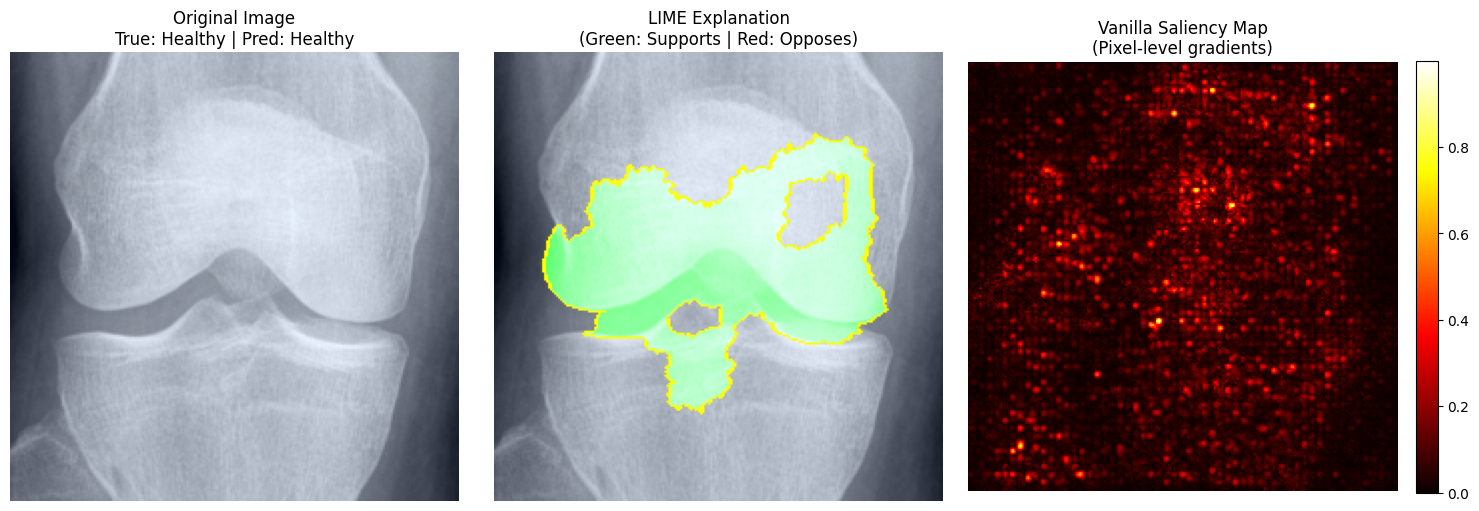

In [21]:
# ============================================================
# EXTRA XAI: LIME (Local Interpretable Model-agnostic Explanations)
# & VANILLA SALIENCY MAPS
# ============================================================

# 1. Automatically install 'lime' if it's not already installed
import sys
try:
    import lime
    from lime import lime_image
    from skimage.segmentation import mark_boundaries
    print("LIME is already installed.")
except ImportError:
    print("Installing 'lime' library to the active kernel...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime", "scikit-image"])
    import lime
    from lime import lime_image
    from skimage.segmentation import mark_boundaries
    print("LIME and Scikit-Image installed successfully!")

# Ensure model is in eval mode on active device
xai_model = cnn_model.eval().to(DEVICE)

# ----------------- PART 1: LIME EXPLANATIONS -----------------
print("\n>>> Running LIME Explanation on Test Sample...")

# Create the LIME Image Explainer
explainer = lime_image.LimeImageExplainer()

# Pick a sample image from the test set
sample_idx = 0  # Feel free to change index
img_tensor, true_label = test_ds[sample_idx]

# Define a prediction function that LIME uses to query the model
def batch_predict(images):
    xai_model.eval()
    batch = []
    for img in images:
        # LIME operates on [0, 1] RGB numpy arrays, so we must normalize them
        # back to match PyTorch's loader transform requirements
        img_t = transforms.ToTensor()(img)
        img_t = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(img_t)
        batch.append(img_t.float()) # Ensure it is a 32-bit float tensor
    
    batch_tensor = torch.stack(batch).to(DEVICE)
    with torch.no_grad():
        logits = xai_model(batch_tensor)
        if isinstance(logits, tuple):
            logits = logits[0]
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Convert PyTorch tensor back to un-normalized numpy image [0, 1] for LIME
img_np = denorm(img_tensor)  # Using denorm function defined in Cell 10

# Generate explanation
explanation = explainer.explain_instance(
    img_np.astype('double'), 
    batch_predict, 
    top_labels=3, 
    hide_color=0, 
    num_samples=250 # Increase to 1000 for higher resolution, but will be slower
)

# Get boundaries for the predicted class
pred_cls = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    pred_cls, 
    positive_only=False, 
    num_features=5, 
    hide_rest=False
)

# ----------------- PART 2: VANILLA SALIENCY MAPS -----------------
print(">>> Running Vanilla Saliency Map...")

# We need the gradient of the input image
saliency_x = img_tensor.unsqueeze(0).to(DEVICE)
saliency_x.requires_grad = True # <-- FIX: Changed from .requires_grad_ = True

# Forward pass
output = xai_model(saliency_x)
if isinstance(output, tuple):
    output = output[0]

# Backward pass to get gradients of the target class score with respect to input pixels
score = output[0, pred_cls]
score.backward()

# Saliency is the maximum absolute gradient across color channels
saliency, _ = torch.max(saliency_x.grad.data.abs(), dim=1)
saliency_map = saliency[0].cpu().numpy()

# Normalize saliency map between 0 and 1
saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)

# ----------------- PLOT THE RESULTS -----------------
plt.figure(figsize=(15, 5))

# Plot 1: Original Image
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original Image\nTrue: {FINAL_CLASSES[true_label]} | Pred: {FINAL_CLASSES[pred_cls]}")
plt.axis("off")

# Plot 2: LIME Explanation
# Green = areas that supported the prediction, Red = areas that opposed the prediction
lime_overlay = mark_boundaries(temp, mask)
plt.subplot(1, 3, 2)
plt.imshow(lime_overlay)
plt.title(f"LIME Explanation\n(Green: Supports | Red: Opposes)")
plt.axis("off")

# Plot 3: Saliency Map
# Bright pixels indicate areas of high influence on model decision
plt.subplot(1, 3, 3)
plt.imshow(saliency_map, cmap="hot")
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Vanilla Saliency Map\n(Pixel-level gradients)")
plt.axis("off")

plt.tight_layout()
plt.show()


gpt - data leakage


In [2]:
import os

def get_patient_ids(folder):
    ids = set()

    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                # Correctly split the extension first, then remove the L/R character
                pid = f.split('.')[0][:-1]  
                ids.add(pid)

    return ids

# Actual path to your local dataset directory
DATA_ROOT = "dataset"

train_ids = get_patient_ids(os.path.join(DATA_ROOT, "train"))
val_ids   = get_patient_ids(os.path.join(DATA_ROOT, "val"))
test_ids  = get_patient_ids(os.path.join(DATA_ROOT, "test"))

print("Train patient count:", len(train_ids))
print("Val patient count:  ", len(val_ids))
print("Test patient count: ", len(test_ids))

print("\n" + "="*30)
print("Patient Overlap Results:")
print("="*30)
print("Train-Val overlap: ", len(train_ids & val_ids))
print("Train-Test overlap:", len(train_ids & test_ids))
print("Val-Test overlap:  ", len(val_ids & test_ids))


Train patient count: 2889
Val patient count:   413
Test patient count:  828

Patient Overlap Results:
Train-Val overlap:  0
Train-Test overlap: 0
Val-Test overlap:   0


In [ ]:
import os
import hashlib

DATA_ROOT = "dataset"

def image_hashes(folder):
    hashes = set()

    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                path = os.path.join(root, f)

                try:
                    with open(path, "rb") as img:
                        file_hash = hashlib.md5(img.read()).hexdigest()
                        hashes.add(file_hash)
                except Exception as e:
                    print(f"Error reading {path}: {e}")

    return hashes

train_hashes = image_hashes(os.path.join(DATA_ROOT, "train"))
val_hashes   = image_hashes(os.path.join(DATA_ROOT, "val"))
test_hashes  = image_hashes(os.path.join(DATA_ROOT, "test"))

print("=" * 40)
print("Duplicate Image Check")
print("=" * 40)

print("Train-Val duplicate images :", len(train_hashes & val_hashes))
print("Train-Test duplicate images:", len(train_hashes & test_hashes))
print("Val-Test duplicate images  :", len(val_hashes & test_hashes))

Duplicate Image Check
Train-Val duplicate images : 0
Train-Test duplicate images: 0
Val-Test duplicate images  : 0


: 